In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
dataSpline = pd.read_csv("../../DataSpline.csv")

# data = pd.read_csv("../../Data.csv")
# data = data.drop(columns=["VD", "VE", "tempo"])
# data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

# data = data.rename(columns={
#     "Setpoint VD": "Wd",
#     "Setpoint VE": "We",
#     "Theta": "theta(Wd,We)",
#     "X": "x(Wd,We)",
#     "Y": "y(Wd,We)",
# })

In [2]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)"]

scaler = StandardScaler()
dataSpline[PREDICTORS] = scaler.fit_transform(dataSpline[PREDICTORS])

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Wd e We como linhas
    for preds in PREDICTORS:
        sns.lineplot(x=df.index, y=df[preds], ax=ax1, marker="o", label=preds,  linewidth=2)

    if PlotOut:
        ax2 = ax1.twinx()
        for target in TARGET:
            sns.lineplot(x=df.index, y=df[target], ax=ax2, marker="o", label=target, linestyle="dashed", linewidth=2, color="red")
            ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")

    # Adicionando legendas
    ax1.legend(loc="upper left")
    if PlotOut:
        ax2.legend(loc="upper right")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)

    # Exibindo o gráfico
    plt.show()

In [4]:
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

def get_XY(data, time_steps, units, output_dim):
    total_samples = (len(data) - time_steps) // time_steps

    X = []
    Y = []
    
    for i in range(total_samples):
        start_idx = i * time_steps
        end_idx = start_idx + time_steps

        X_seq = data.iloc[start_idx:end_idx][PREDICTORS].values  # shape: (time_steps, features)
        Y_target = data.iloc[end_idx][TARGET]  # escalar

        X.append(X_seq)
        Y.append(Y_target)

    X = np.array(X)  # shape: (batch, time_steps, features)
    Y =  Y = np.array(Y).reshape(-1, 1).repeat(output_dim, axis=1)  # shape (batch, output_dim)
    h0 = np.full((X.shape[0], units), fill_value=Y[0]) # shape (batch, units)

    print(f"Shape X (batch, time_steps, features): {X.shape}")
    print(f"Shape Y (batch, output_dim): {Y.shape}")
    print(f"Shape h0 (batch, units): {h0.shape}")
    
    return X, Y, h0

In [5]:
def PlotOut(valuer):
    sns.set_theme(style="whitegrid")

    fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharey=False)

    datasets = [
        ('Treinamento', valuer.train_samples_y, valuer.train_pred),
        ('Validação', valuer.val_samples_y, valuer.val_pred),
        ('Teste', valuer.test_samples_y, valuer.test_pred)
    ]

    times = [
        np.arange(len(valuer.train_samples_y)),
        np.arange(len(valuer.val_samples_y)),
        np.arange(len(valuer.test_samples_y))
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        # Garante que são vetores 1D
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)

        sns.lineplot(x=times[i], y=y_true, ax=axs[i], marker="o", label="Amostras Reais", linewidth=2)
        sns.lineplot(x=times[i], y=y_pred, ax=axs[i], marker="o", label="Valores preditos", linewidth=2)

        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Tempo')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação temporal: Predição (curva) vs Amostras Reais (pontos)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()  
    
    path = f"./content/models/{valuer.fileName}.png"
    fig.savefig(path)    
    
    
def PlotHist(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from keras import layers, models, regularizers, initializers, optimizers
from keras.callbacks import EarlyStopping
from itertools import product


class EvalRNN:
    
    def __init__(self, dataset, epochs, time_steps, act_h, act_o):
        self.epochs = epochs
        self.Dataset = dataset
        self.output_dim = np.size(TARGET)
        self.time_steps = time_steps
        self.act_h = act_h
        self.act_o = act_o
        self.better_metrics = {}


    def SplitData(self, units):
        self.units = units
                
        train_data, test_data = train_test_split(self.Dataset, test_size=0.25, shuffle=False)
        train_data, val_data = train_test_split(train_data, test_size=0.15, shuffle=False)
                
        self.train_samples_x, self.train_samples_y, self.h0_train = get_XY(train_data, self.time_steps, units, self.output_dim)       
        self.val_samples_x, self.val_samples_y, self.h0_val = get_XY(val_data, self.time_steps, units, self.output_dim)
        self.test_samples_x, self.test_samples_y, self.h0_test = get_XY(test_data, self.time_steps, units, self.output_dim)

        self.time_steps = self.train_samples_x.shape[1]
        self.features = self.train_samples_x.shape[2]
        
    def BuildModel(self, hidden_sizes, param_reg):
        initializer = initializers.RandomUniform(minval=-0.5,
                                                maxval=0.5,
                                                # seed=np.random.randint(1, 10000)
                                                )
        regularizer = regularizers.L2(param_reg)
        inputs = layers.Input((self.time_steps, self.features))
        initial_state = layers.Input((self.units,))

        # Primeira camada RNN com estado inicial
        rnn_layer = layers.SimpleRNN(
            hidden_sizes[0],
            activation=self.act_h,
            kernel_regularizer=regularizer,
            kernel_initializer=initializer,
            return_sequences=(len(hidden_sizes) > 1)  
        )(inputs, initial_state=initial_state)

        # Demais camadas RNN
        for size in hidden_sizes[1:-1]:
            rnn_layer = layers.SimpleRNN(
                size,
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=True 
            )(rnn_layer)

        # Última camada RNN
        if len(hidden_sizes) > 1:
            rnn_layer = layers.SimpleRNN(
                hidden_sizes[-1],
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=False  
            )(rnn_layer)
       
       # Output mlp layer
        output = layers.Dense(self.output_dim,
                            activation=self.act_o,
                            kernel_regularizer=regularizer,
                            kernel_initializer=initializer)(rnn_layer)
        
        model = models.Model([inputs] + [initial_state], output)
        return(model)
    
    def CompileModel(self, model, lr):
        model.compile(loss="mse", optimizer=optimizers.Adam(learning_rate=lr))
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        history = model.fit(
            [self.train_samples_x, self.h0_train],
            self.train_samples_y,
            epochs=self.epochs,
            validation_data=([self.val_samples_x, self.h0_val], self.val_samples_y),
            callbacks=[early_stop],
            verbose=False,
            shuffle=False   
        )
        PlotHist(history)
    
    def ComputeMetrics(self, model):
        self.train_pred = np.squeeze(model.predict([self.train_samples_x, self.h0_train]))
        self.val_pred = np.squeeze(model.predict([self.val_samples_x, self.h0_val]))
        self.test_pred = np.squeeze(model.predict([self.test_samples_x, self.h0_test]))


        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
                    
                    'r2_val': r2_score(self.val_samples_y, self.val_pred),
                    'mse_val': mean_squared_error(self.val_samples_y, self.val_pred),
                    'mape_val': mean_absolute_percentage_error(self.val_samples_y, self.val_pred),
                    'rmse_val': root_mean_squared_error(self.val_samples_y, self.val_pred),
            })

    def SaveModelWeights(self, model):
        path = f"./content/models/{self.fileName}.weights.h5"
        open(path,'w').close()
        model.save_weights(path) 

    def LoopWeights(self, model, run_times, lr, boundarie, sort_by, idx):
        better_model = 0
        save = False

        for i in range(run_times):
            print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
            self.CompileModel(model, lr)
            metrics = self.ComputeMetrics(model)
            
            if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
                self.fileName = f"model_{idx}_{better_model}"
                self.SaveModelWeights(model)
                self.better_metrics[self.fileName] = metrics
                better_model += 1
                save = True
        return(save)

    def Evaluate(self, hidden_sizes, regularizers, learning_rate, run_times, boundarie, sort_by):
        for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
            header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
            print(f"Testando combinacao{count}: {header}")
            
            self.SplitData(units=hidden_size[0])        
            model = self.BuildModel(hidden_size, reg)
            
            if (self.LoopWeights(model, run_times, lr, boundarie, sort_by, f"{count}") == True):        
                self.DisplayBetterResults(header, sort_by, f"{count}")
                # PlotOut(self)
                
        self.better_metrics = {}
  
                
    def DisplayBetterResults(self, header, sort_by, dataset=0):
        df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
        df = df.sort_values([sort_by])
        display(df)
        path = f'./content/results/metrics_{dataset}'
        df.to_excel(f"{path}.xlsx", index=True)
        print(f"DataFrame salvo em {path}")
        with open(f"{path}.txt", 'w') as arquivo:
            arquivo.write(header)            
       

2025-06-03 01:15:35.642459: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 01:15:35.647271: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 01:15:35.663821: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748913335.691153   10671 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748913335.699466   10671 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748913335.721126   10671 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [ ]:
Valuer = EvalRNN(dataset = dataSpline,
                epochs = 2000,
                time_steps = 2,
                act_h = 'tanh',
                act_o = 'sigmoid',
                )        

: 

Testando combinacao1: Hidden Size=[5], regularizer=0.2, learning_rate=0.01


Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 5)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 5)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 5)
+++++++++++ [1] | 1 ++++++++++++++++++


2025-06-03 01:15:42.743069: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


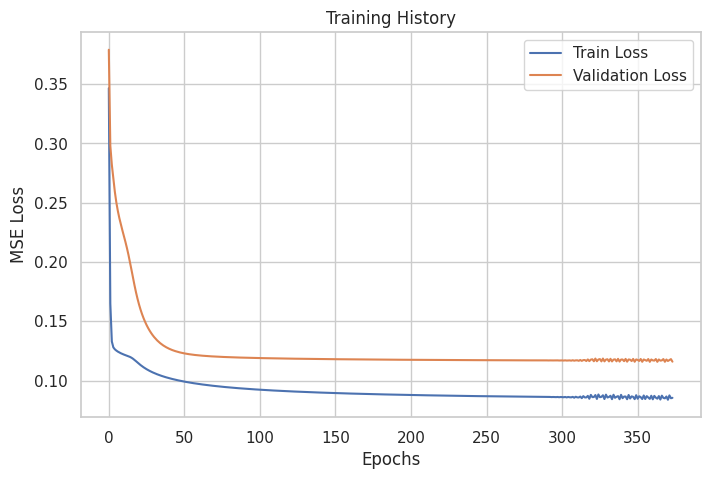

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [1] | 2 ++++++++++++++++++


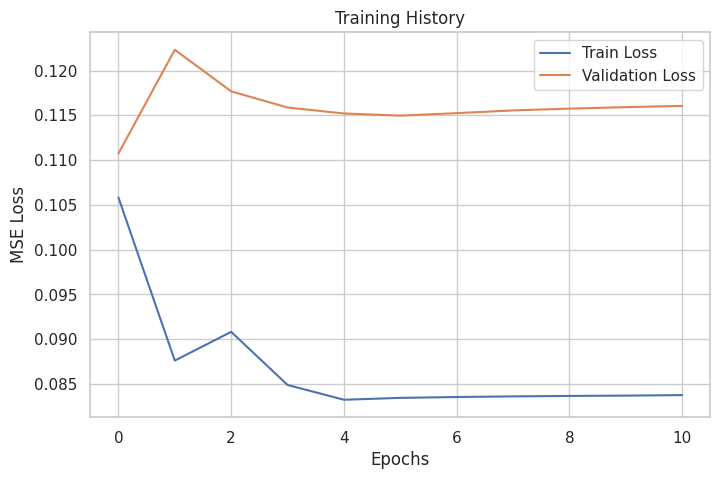

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
+++++++++++ [1] | 3 ++++++++++++++++++


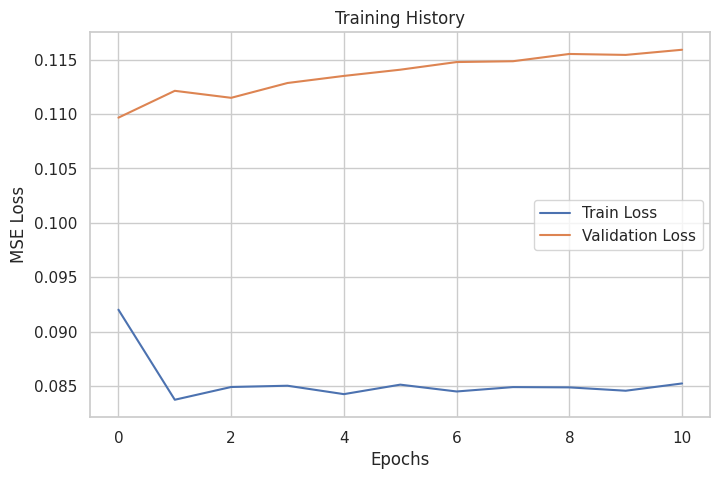

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
+++++++++++ [1] | 4 ++++++++++++++++++


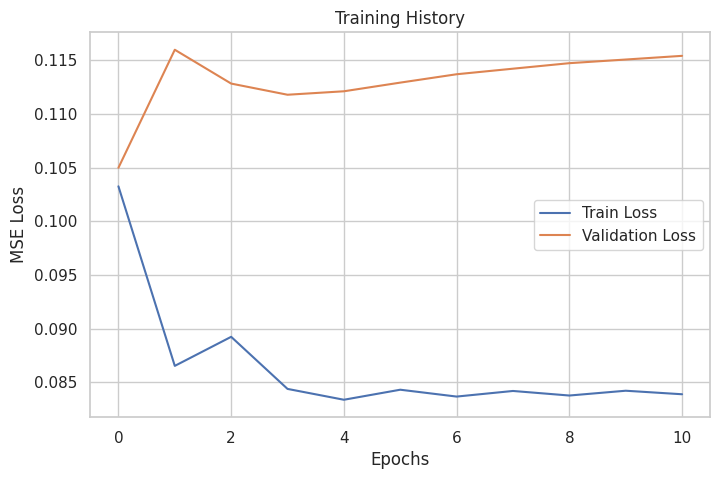

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [1] | 5 ++++++++++++++++++


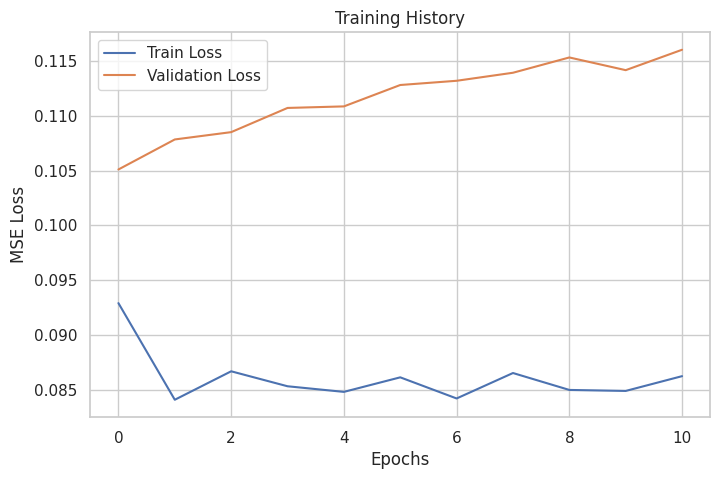

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [1] | 6 ++++++++++++++++++


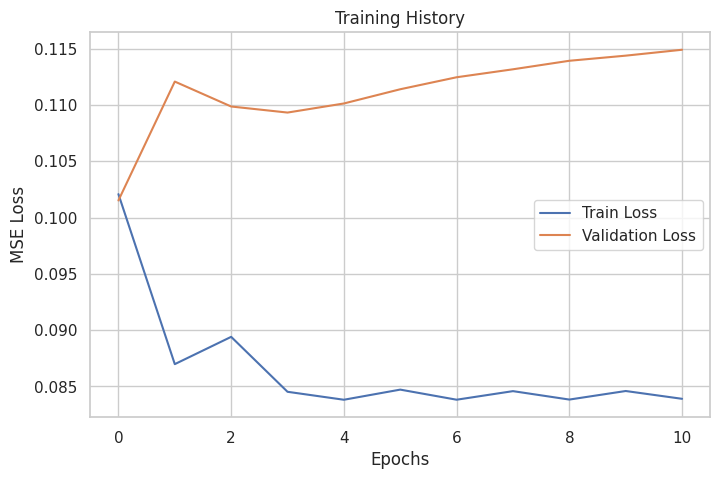

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
+++++++++++ [1] | 7 ++++++++++++++++++


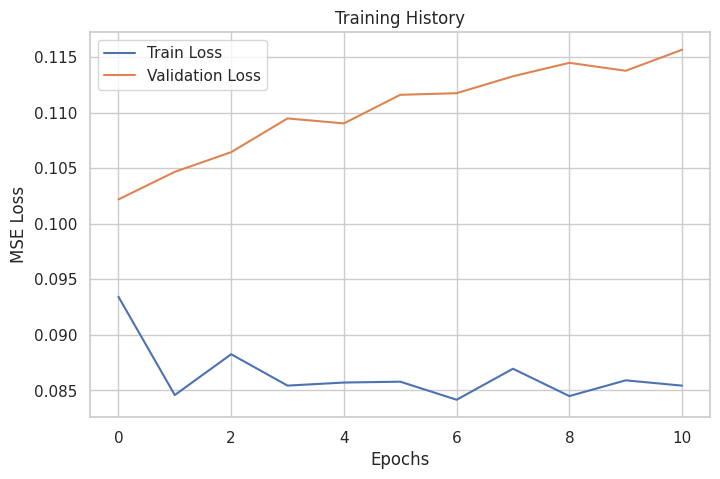

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [1] | 8 ++++++++++++++++++


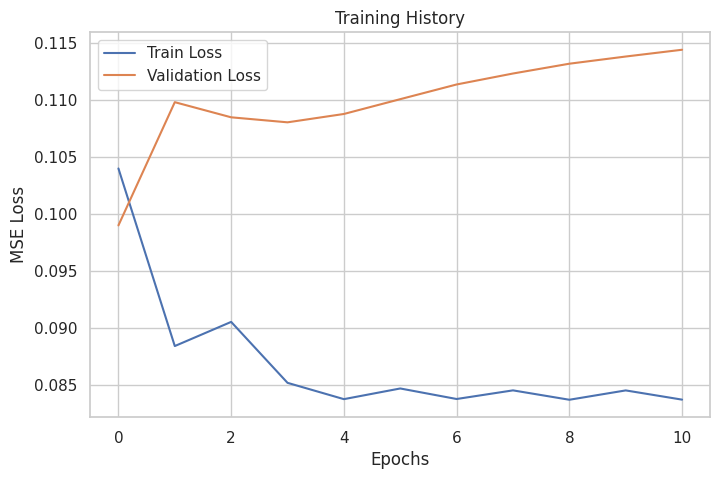

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [1] | 9 ++++++++++++++++++


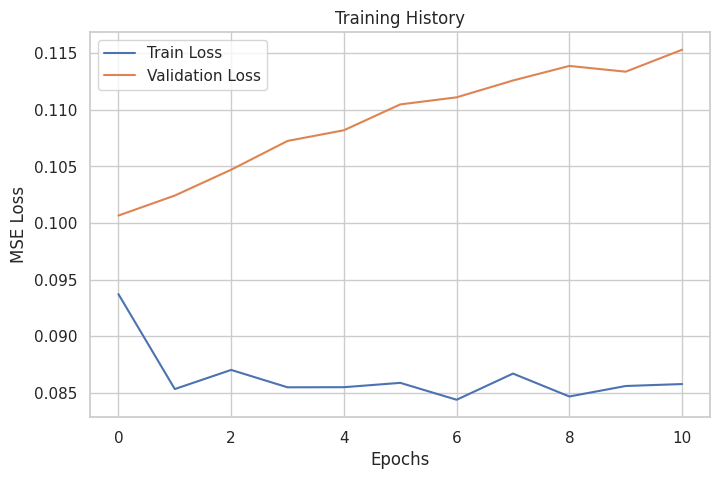

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
+++++++++++ [1] | 10 ++++++++++++++++++


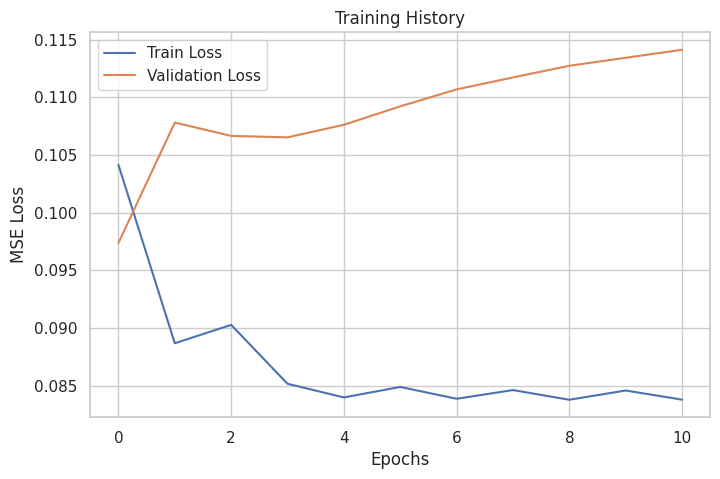

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_1_0,0.441189,0.066381,15.729758,0.257645,-19.724236,0.618041,1.400332,0.786156,-42.432479,0.088839,3.637381,0.298059
model_1_3,0.478022,0.062006,13.302598,0.249009,-18.433426,0.579546,1.348915,0.761279,-35.399458,0.074453,3.298648,0.272862
model_1_4,0.480321,0.061733,12.919051,0.248460,-18.314125,0.575988,1.344073,0.758939,-34.769989,0.073166,3.266750,0.270492
model_1_1,0.489349,0.060660,13.824411,0.246293,-19.001572,0.596489,1.371760,0.772327,-38.445784,0.080685,3.449155,0.284050
model_1_2,0.496297,0.059835,13.158299,0.244611,-18.608284,0.584761,1.355983,0.764697,-36.328531,0.076354,3.345213,0.276322


DataFrame salvo em ./content/results/metrics_1
Testando combinacao2: Hidden Size=[5], regularizer=0.2, learning_rate=0.09
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 5)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 5)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 5)
+++++++++++ [2] | 1 ++++++++++++++++++


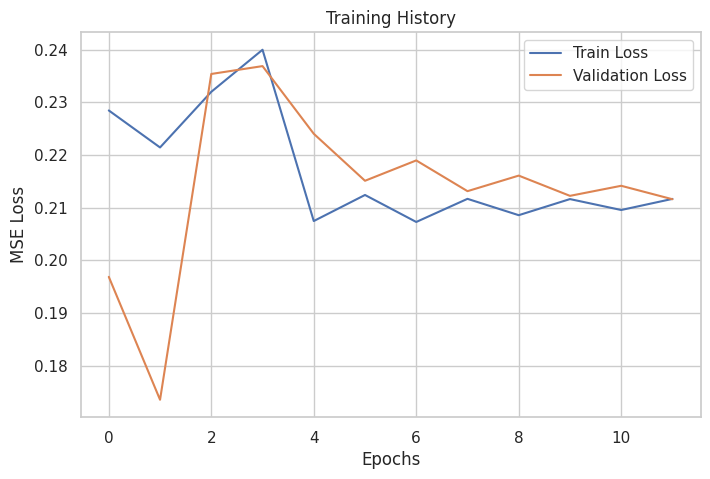

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
+++++++++++ [2] | 2 ++++++++++++++++++


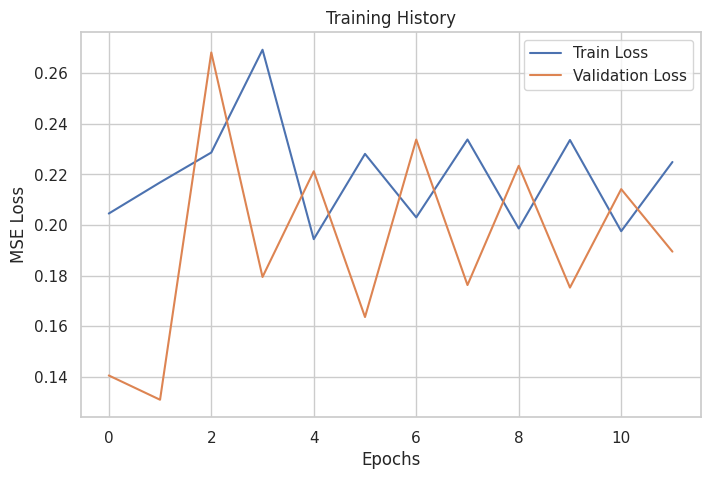

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [2] | 3 ++++++++++++++++++


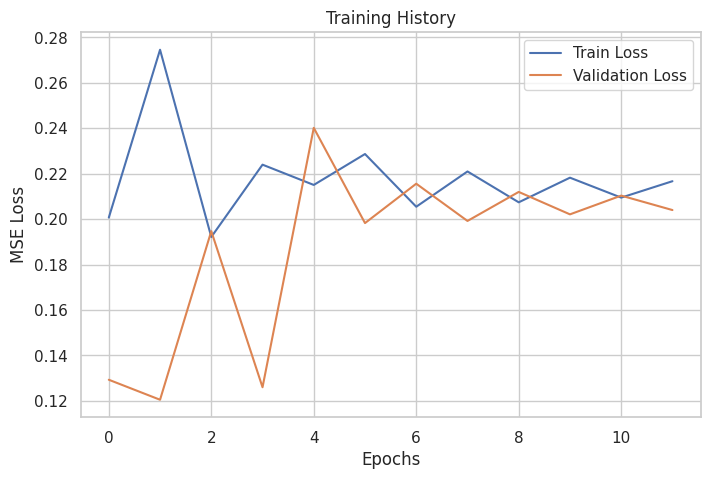

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
+++++++++++ [2] | 4 ++++++++++++++++++


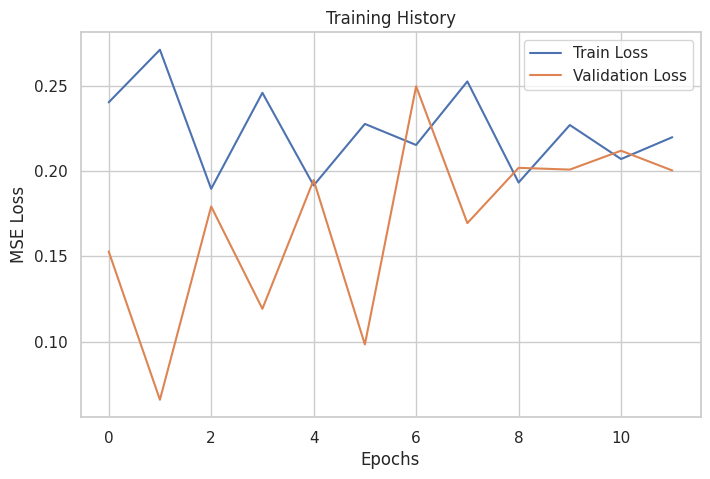

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
+++++++++++ [2] | 5 ++++++++++++++++++


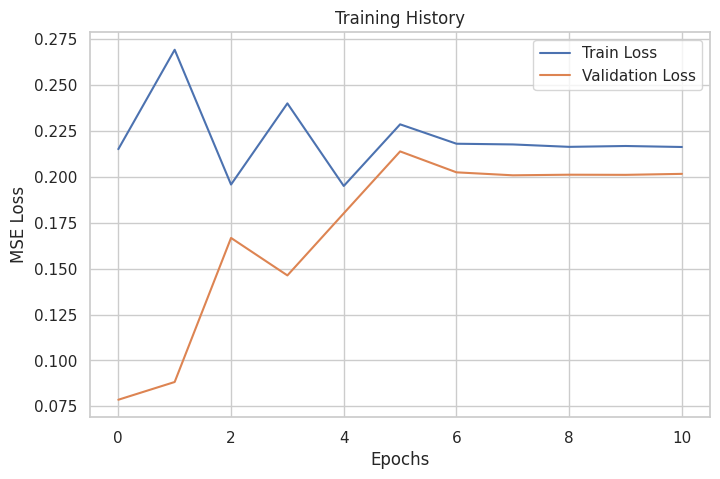

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
+++++++++++ [2] | 6 ++++++++++++++++++


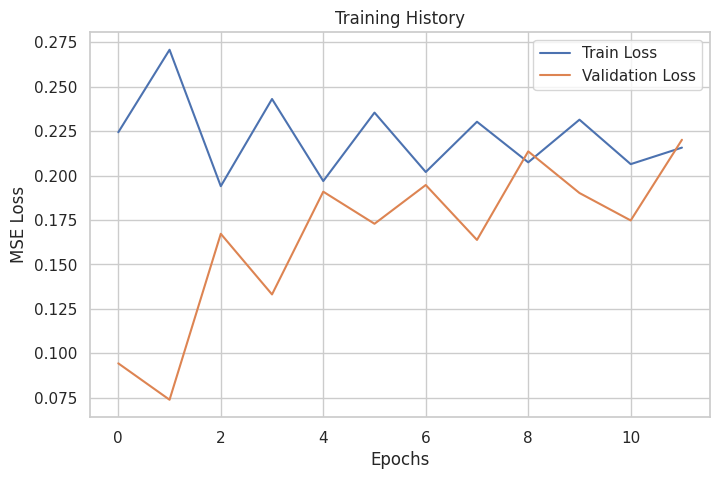

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
+++++++++++ [2] | 7 ++++++++++++++++++


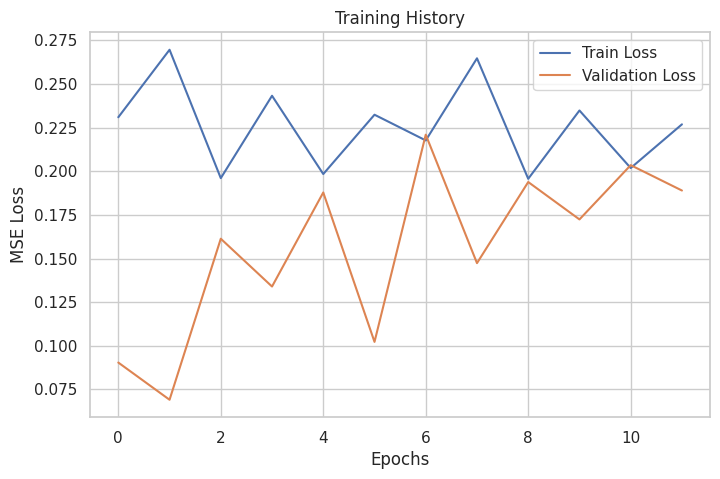

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
+++++++++++ [2] | 8 ++++++++++++++++++


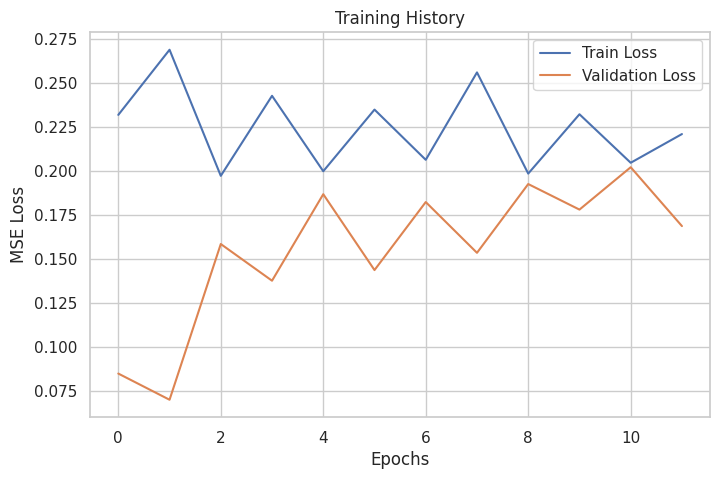

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
+++++++++++ [2] | 9 ++++++++++++++++++


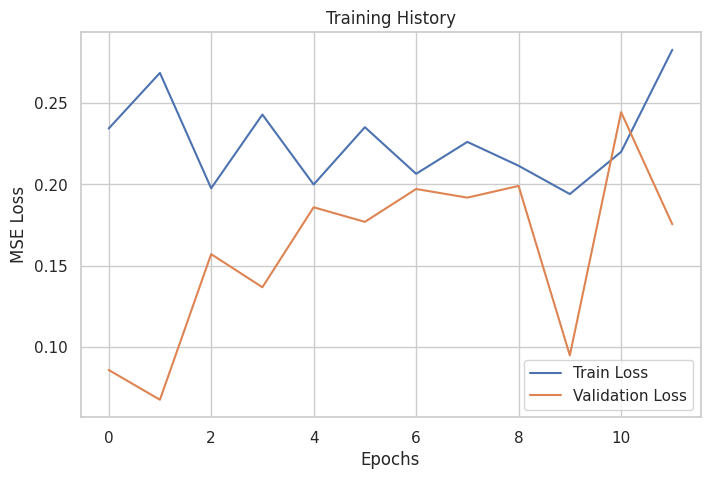

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
+++++++++++ [2] | 10 ++++++++++++++++++


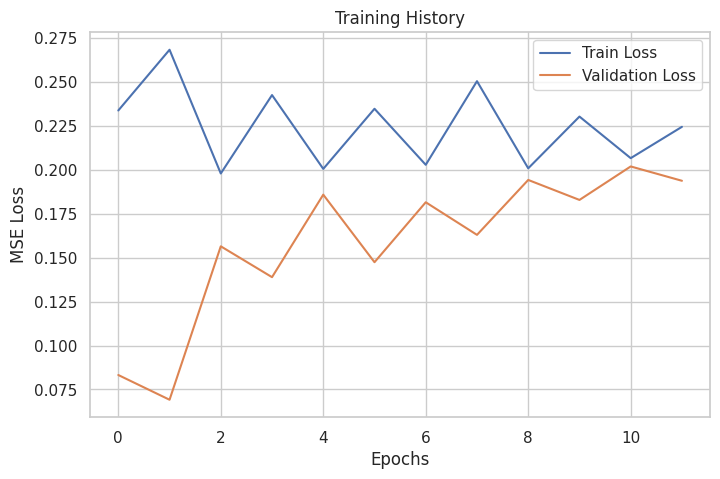

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_8,-0.370120,0.162756,10.219642,0.403431,-13.901829,0.444404,1.152371,0.666637,-29.221691,0.061817,2.972065,0.248631
model_2_9,-0.363320,0.161948,10.346664,0.402428,-13.839237,0.442538,1.149448,0.665235,-29.685967,0.062767,2.997742,0.250533
model_2_7,-0.355395,0.161007,10.496241,0.401257,-13.946732,0.445743,1.154465,0.667640,-30.237403,0.063895,3.027980,0.252774
model_2_6,-0.355037,0.160965,10.503041,0.401204,-14.144492,0.451641,1.163644,0.672042,-30.262705,0.063946,3.029361,0.252876
model_2_3,-0.351078,0.160494,10.578398,0.400617,-15.582542,0.494527,1.228552,0.703226,-30.538350,0.064510,3.044364,0.253989
model_2_5,-0.321763,0.157012,11.150919,0.396247,-14.470820,0.461373,1.178653,0.679244,-32.708778,0.068950,3.160228,0.262583
model_2_4,-0.284635,0.152601,11.915775,0.390642,-15.380941,0.488515,1.219639,0.698938,-35.715088,0.075099,3.314535,0.274042
model_2_2,-0.115978,0.132567,16.304169,0.364097,-16.326716,0.516720,1.260969,0.718832,-54.967311,0.114479,4.177593,0.338347
model_2_1,-0.046833,0.124353,13.024367,0.352637,-30.120950,0.928093,1.764585,0.963376,-47.707982,0.099630,3.820885,0.315642
model_2_0,-0.012879,0.120320,17.850301,0.346871,-22.798703,0.709728,1.514526,0.842454,-62.062779,0.128992,4.446992,0.359155


DataFrame salvo em ./content/results/metrics_2
Testando combinacao3: Hidden Size=[5], regularizer=0.1, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 5)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 5)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 5)
+++++++++++ [3] | 1 ++++++++++++++++++


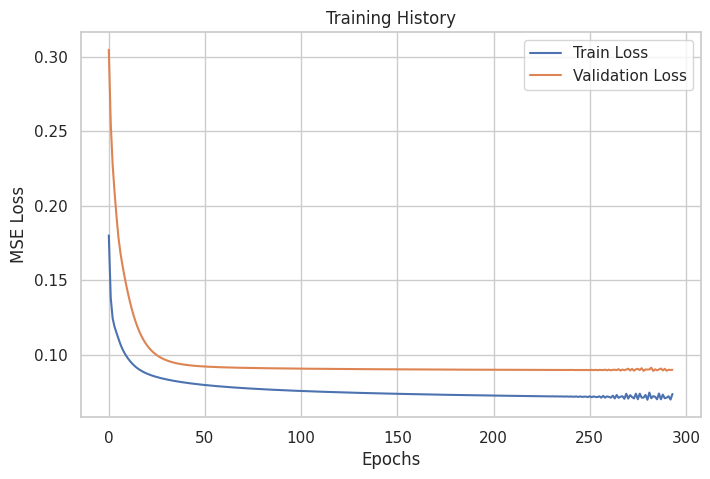

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
+++++++++++ [3] | 2 ++++++++++++++++++


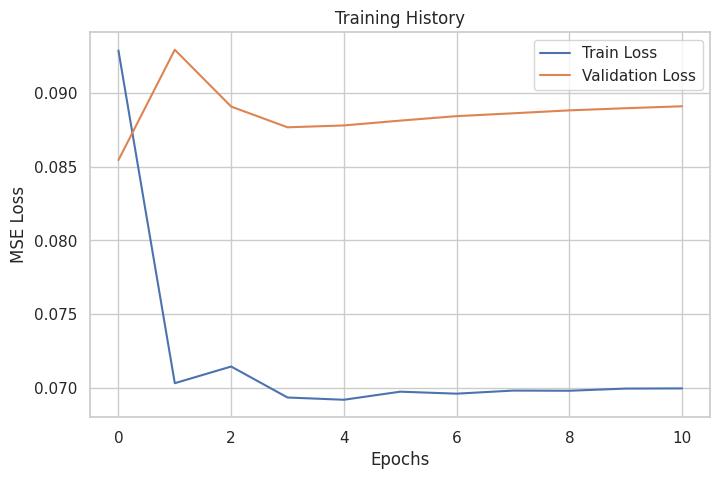

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [3] | 3 ++++++++++++++++++


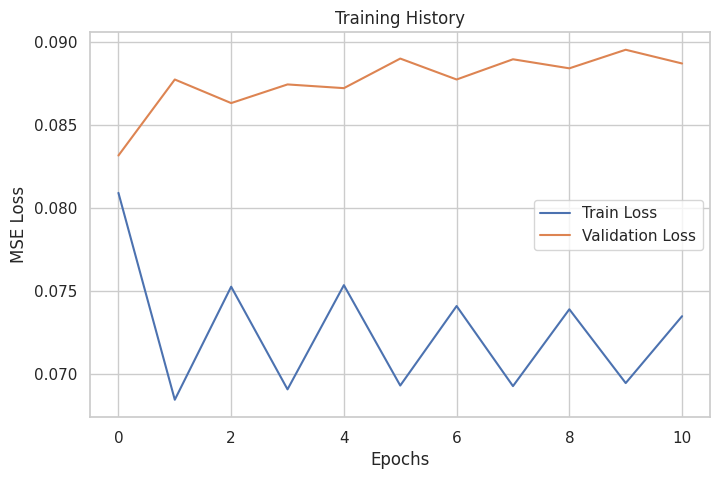

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
+++++++++++ [3] | 4 ++++++++++++++++++


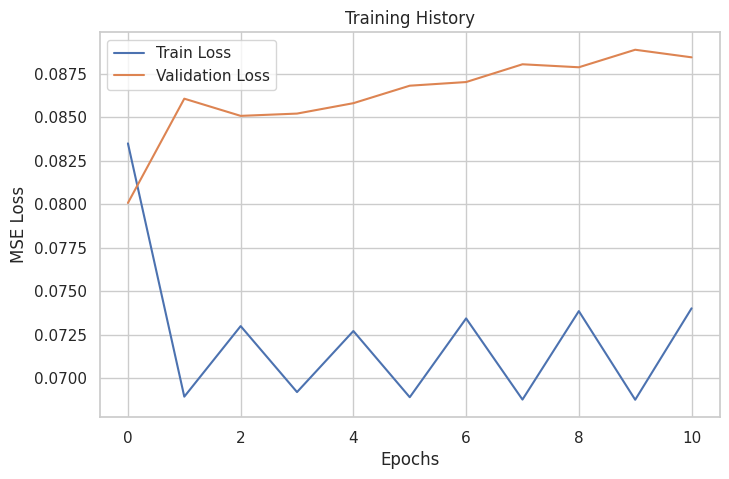

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [3] | 5 ++++++++++++++++++


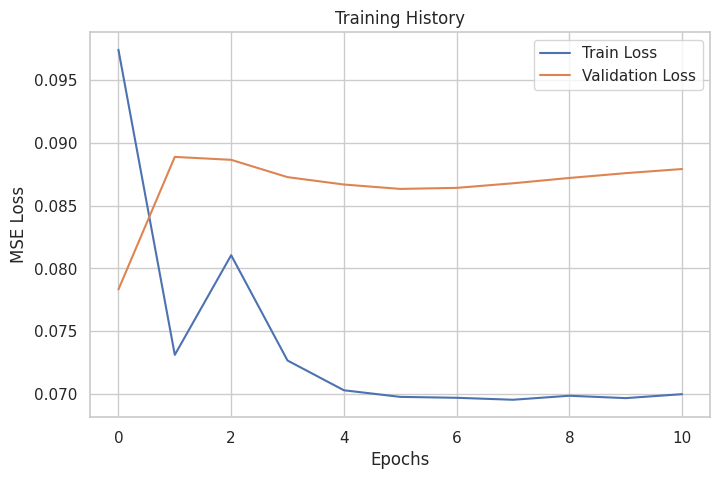

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [3] | 6 ++++++++++++++++++


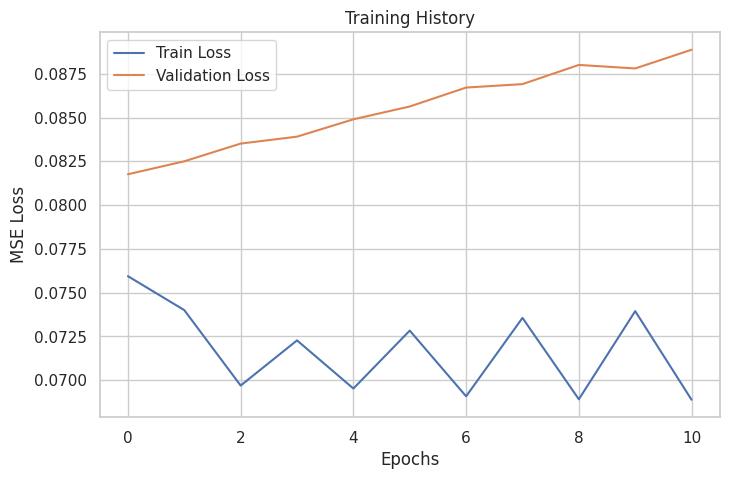

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
+++++++++++ [3] | 7 ++++++++++++++++++


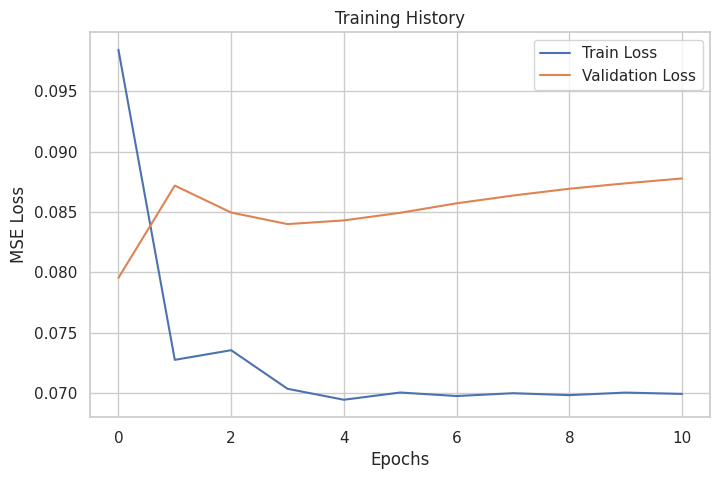

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
+++++++++++ [3] | 8 ++++++++++++++++++


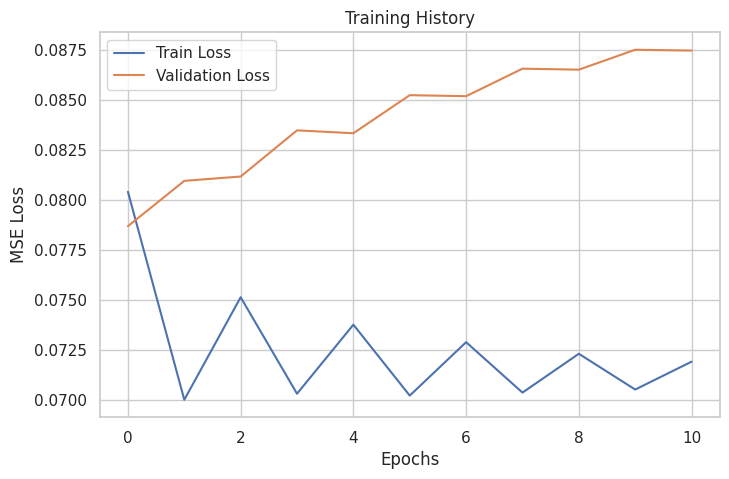

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [3] | 9 ++++++++++++++++++


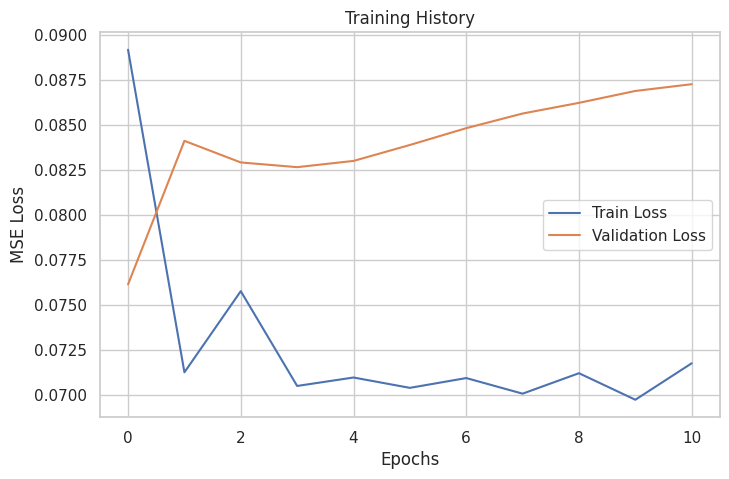

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [3] | 10 ++++++++++++++++++


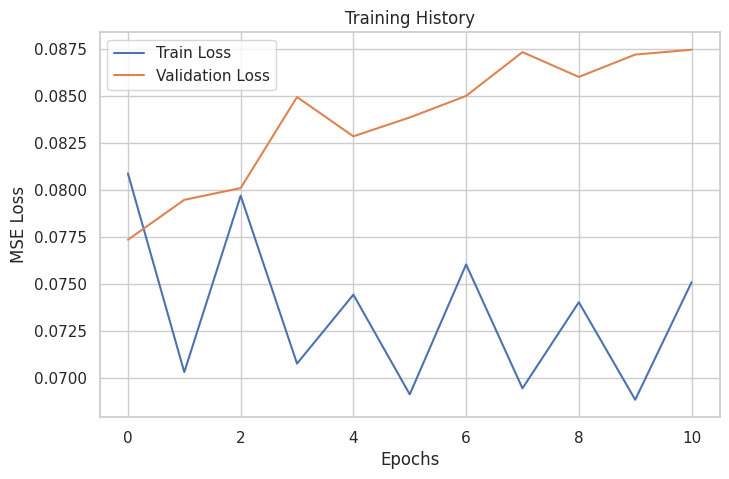

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Testando combinacao4: Hidden Size=[5], regularizer=0.1, learning_rate=0.09
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 5)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 5)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 5)
+++++++++++ [4] | 1 ++++++++++++++++++


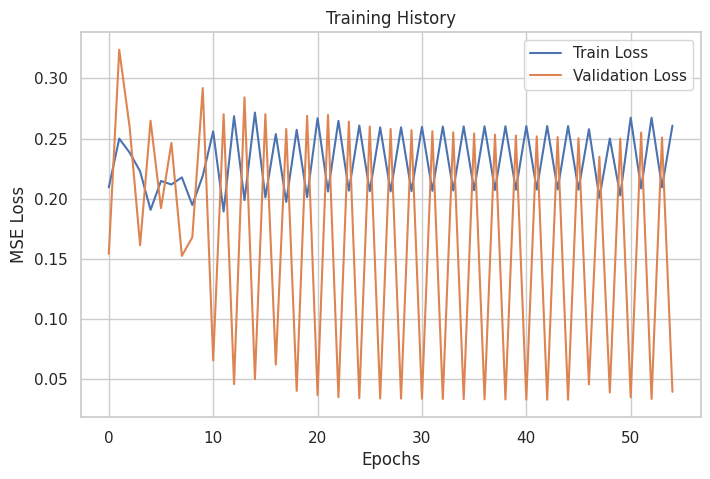

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [4] | 2 ++++++++++++++++++


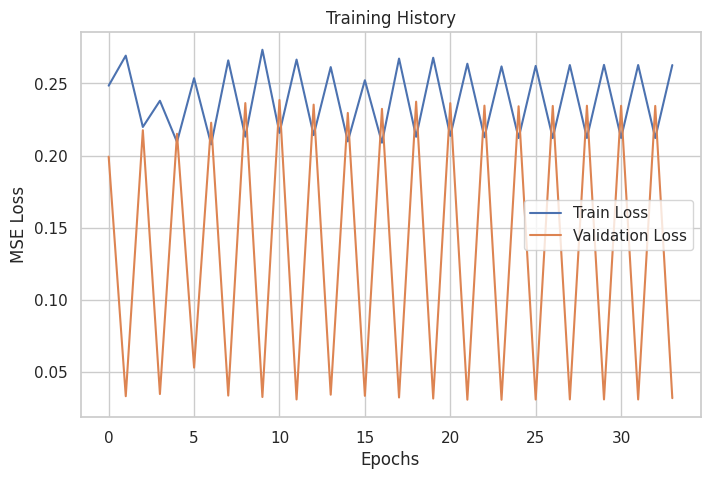

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [4] | 3 ++++++++++++++++++


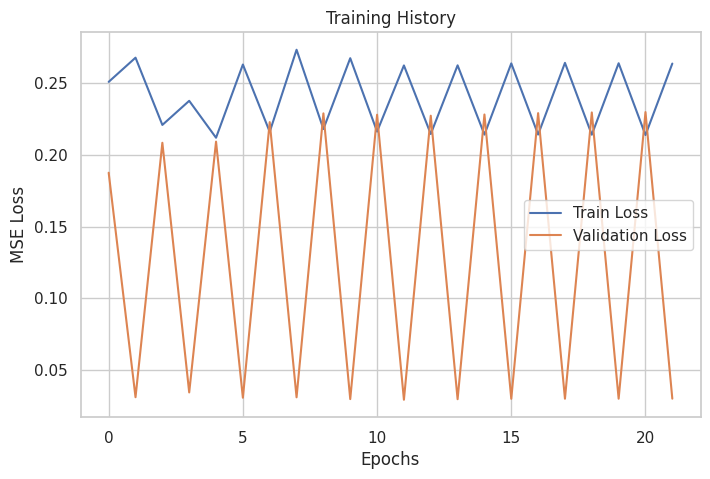

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [4] | 4 ++++++++++++++++++


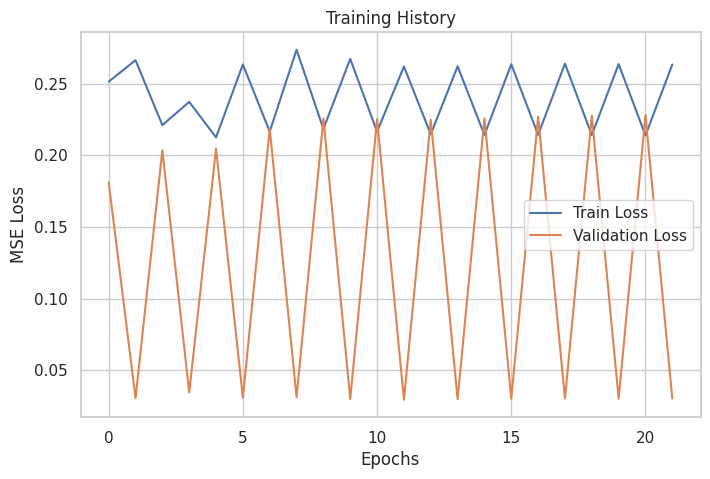

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
+++++++++++ [4] | 5 ++++++++++++++++++


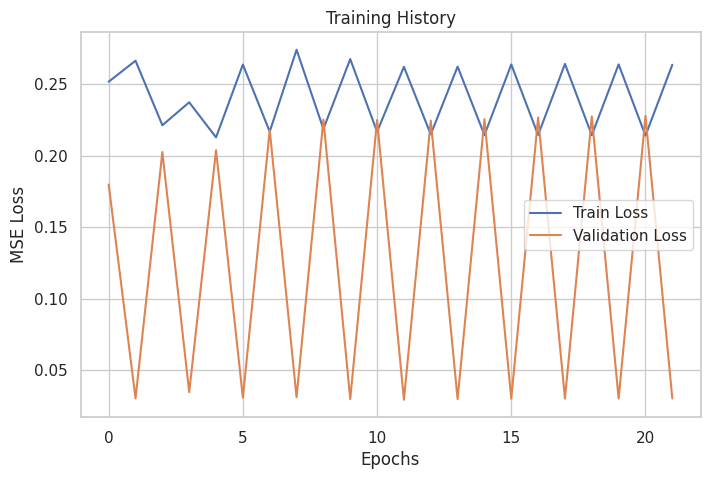

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [4] | 6 ++++++++++++++++++


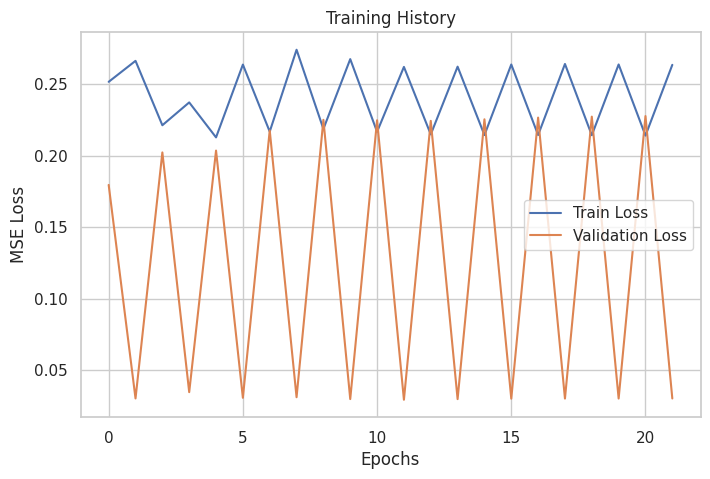

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [4] | 7 ++++++++++++++++++


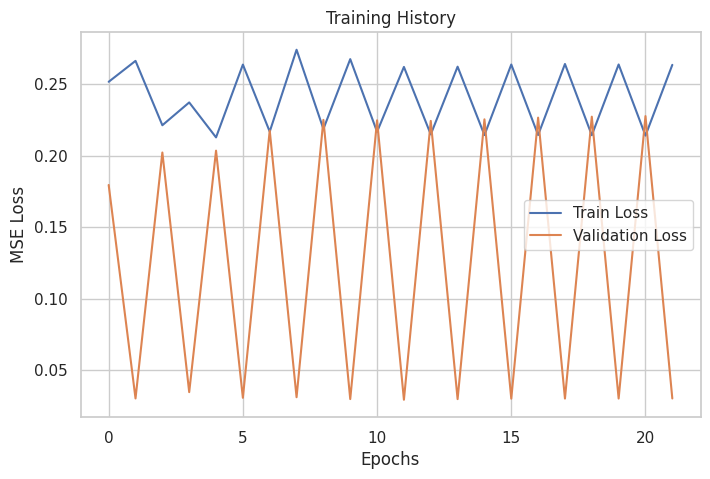

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
+++++++++++ [4] | 8 ++++++++++++++++++


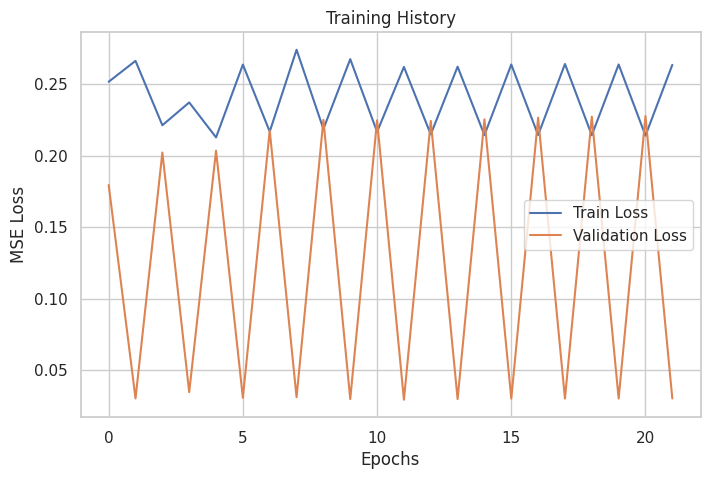

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [4] | 9 ++++++++++++++++++


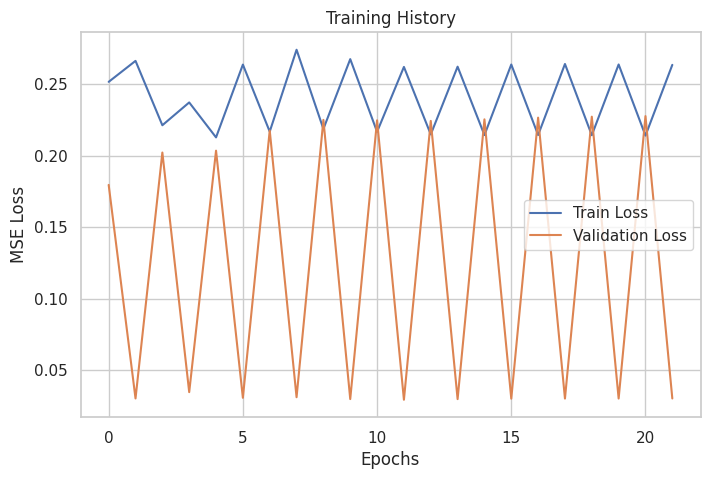

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [4] | 10 ++++++++++++++++++


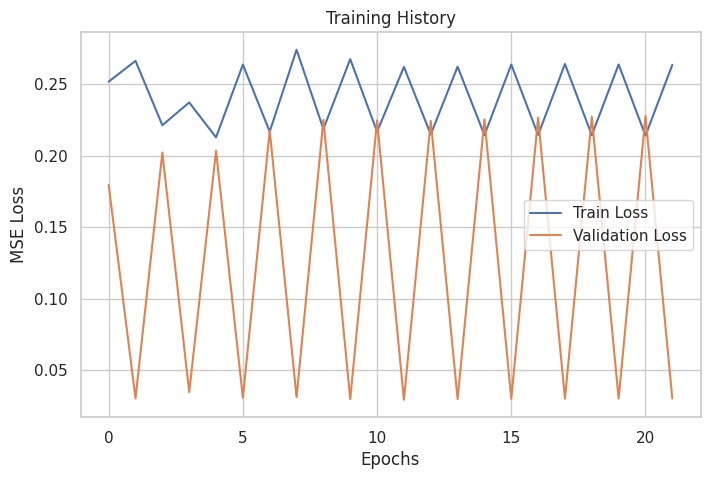

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_4_9,-0.790121,0.212648,3.939881,0.461138,-12.895900,0.414405,1.104556,0.643743,-10.679885,0.023891,1.688813,0.154566
model_4_8,-0.790120,0.212648,3.939887,0.461138,-12.895904,0.414405,1.104556,0.643743,-10.679899,0.023891,1.688814,0.154566
model_4_7,-0.790119,0.212648,3.939901,0.461138,-12.895913,0.414406,1.104557,0.643744,-10.679929,0.023891,1.688817,0.154566
model_4_6,-0.790113,0.212647,3.939983,0.461137,-12.895966,0.414407,1.104559,0.643745,-10.680115,0.023891,1.688834,0.154568
model_4_5,-0.790082,0.212643,3.940363,0.461133,-12.896213,0.414415,1.104571,0.643750,-10.680974,0.023893,1.688913,0.154573
model_4_4,-0.789935,0.212626,3.942180,0.461114,-12.897396,0.414450,1.104628,0.643778,-10.685086,0.023901,1.689291,0.154601
model_4_3,-0.789239,0.212543,3.950809,0.461024,-12.903015,0.414618,1.104901,0.643908,-10.704620,0.023941,1.691084,0.154730
model_4_2,-0.785910,0.212148,3.992097,0.460595,-12.929916,0.415420,1.106203,0.644531,-10.798334,0.024133,1.699662,0.155348
model_4_1,-0.766906,0.209890,4.229813,0.458138,-13.085217,0.420051,1.113694,0.648114,-11.345197,0.025252,1.748995,0.158907
model_4_0,-0.728062,0.205276,4.726552,0.453074,-13.404339,0.429568,1.128948,0.655414,-12.510906,0.027636,1.850333,0.166241


DataFrame salvo em ./content/results/metrics_4
Testando combinacao5: Hidden Size=[10], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 10)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 10)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 10)
+++++++++++ [5] | 1 ++++++++++++++++++


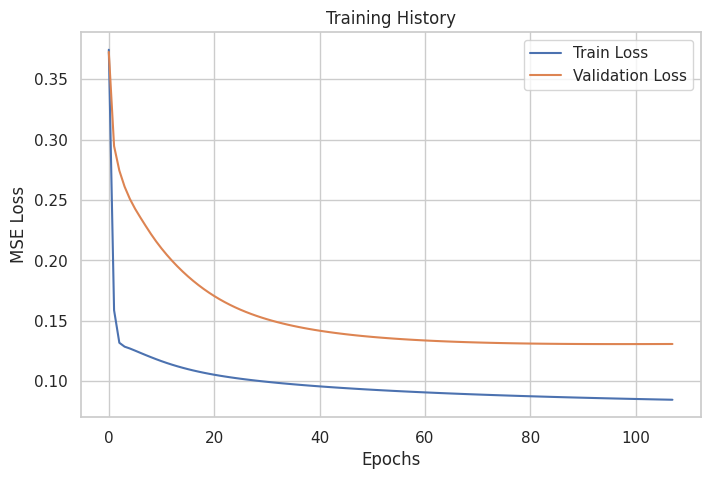

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [5] | 2 ++++++++++++++++++


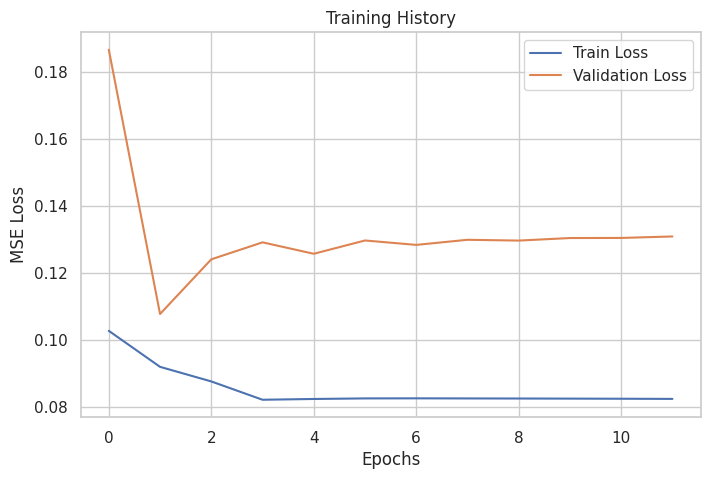

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [5] | 3 ++++++++++++++++++


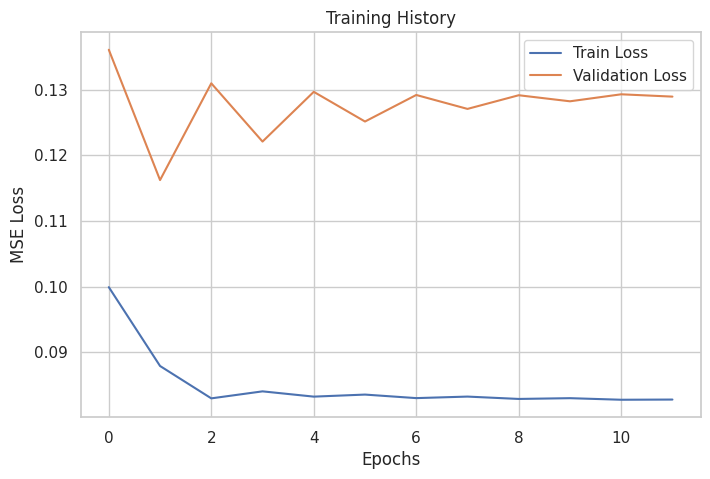

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [5] | 4 ++++++++++++++++++


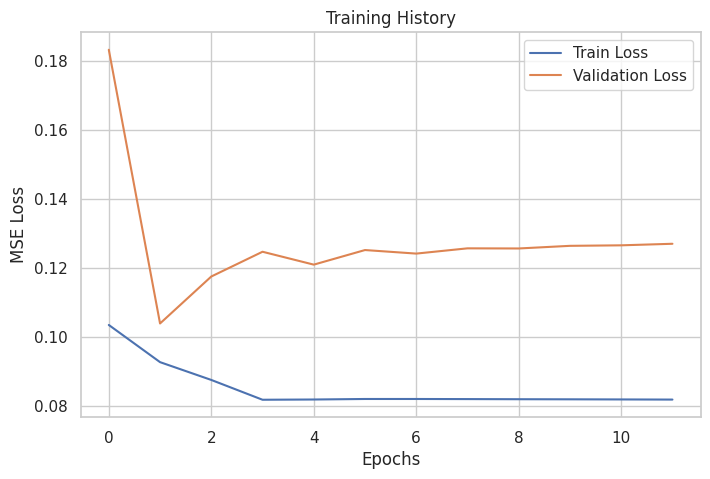

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [5] | 5 ++++++++++++++++++


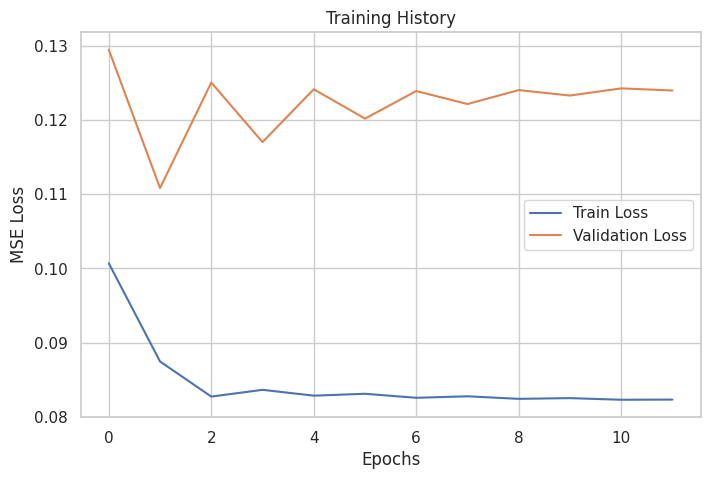

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [5] | 6 ++++++++++++++++++


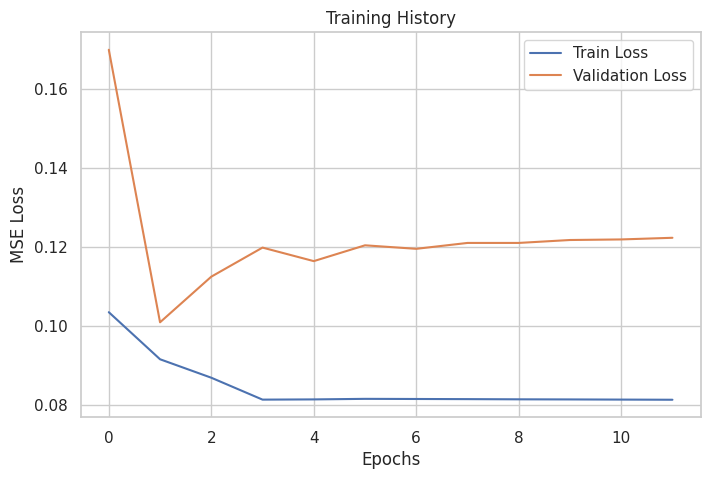

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [5] | 7 ++++++++++++++++++


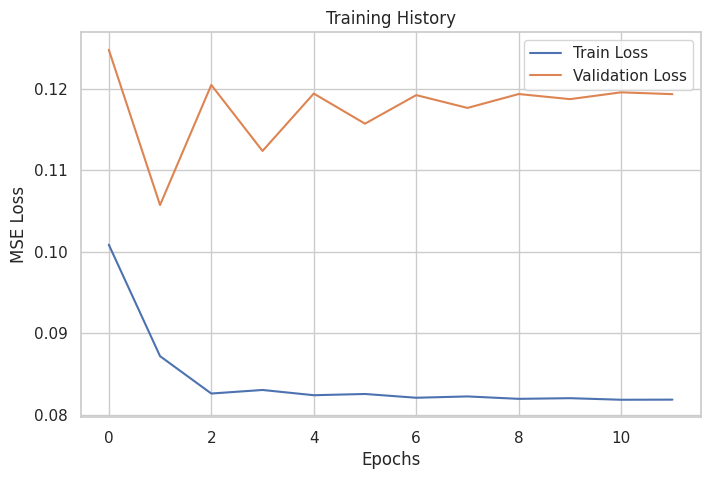

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [5] | 8 ++++++++++++++++++


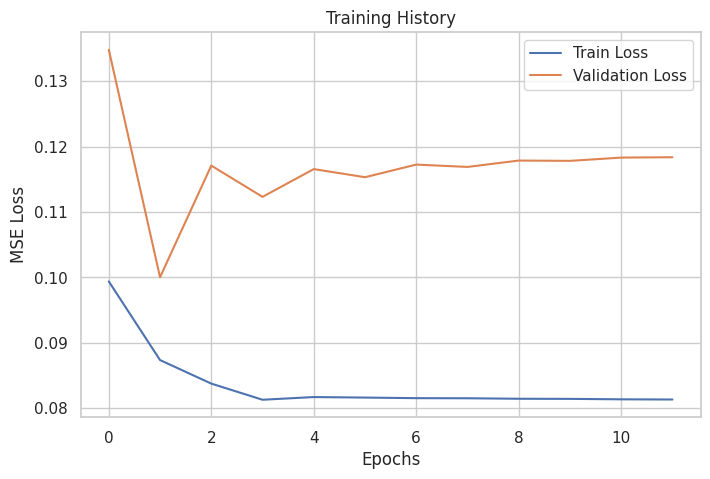

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [5] | 9 ++++++++++++++++++


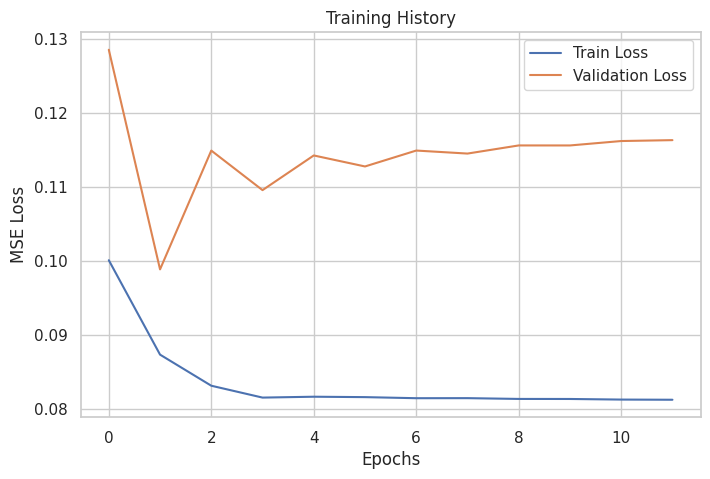

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [5] | 10 ++++++++++++++++++


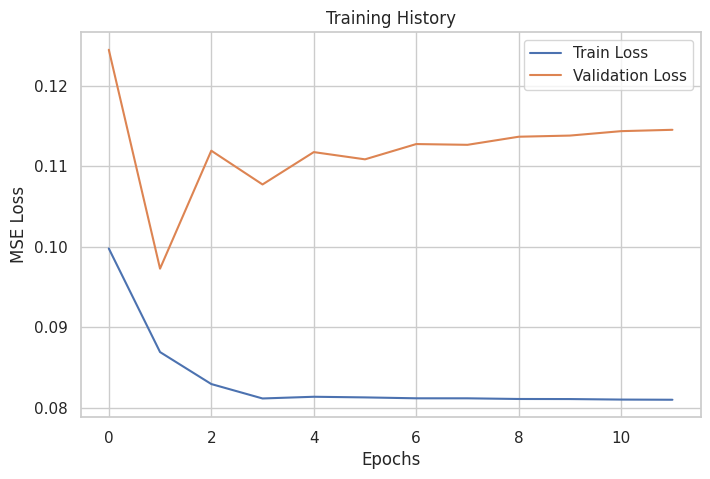

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Testando combinacao6: Hidden Size=[10], regularizer=0.2, learning_rate=0.09
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 10)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 10)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 10)
+++++++++++ [6] | 1 ++++++++++++++++++


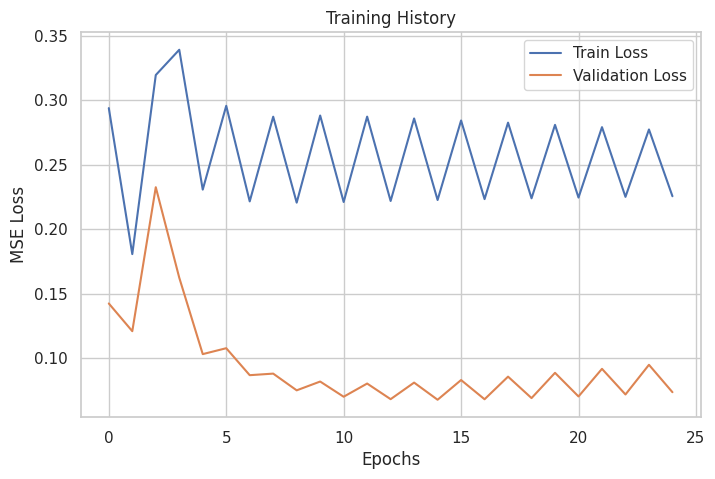

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
+++++++++++ [6] | 2 ++++++++++++++++++


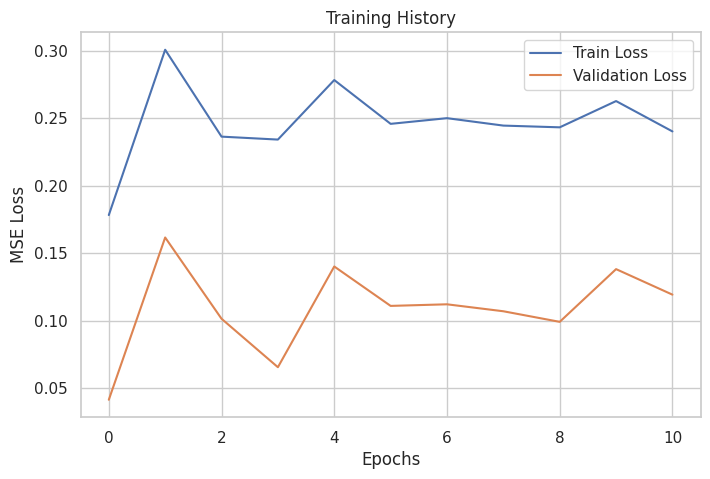

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
+++++++++++ [6] | 3 ++++++++++++++++++


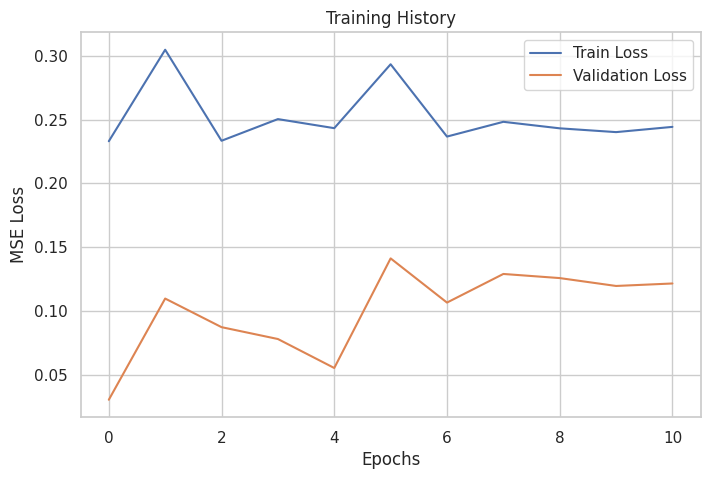

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [6] | 4 ++++++++++++++++++


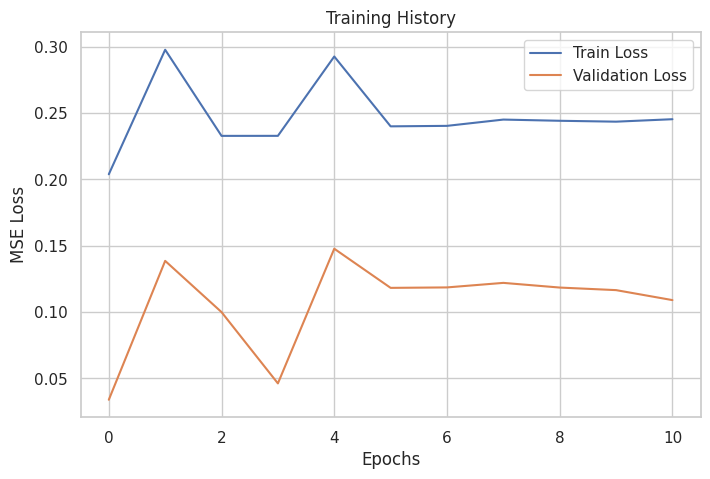

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [6] | 5 ++++++++++++++++++


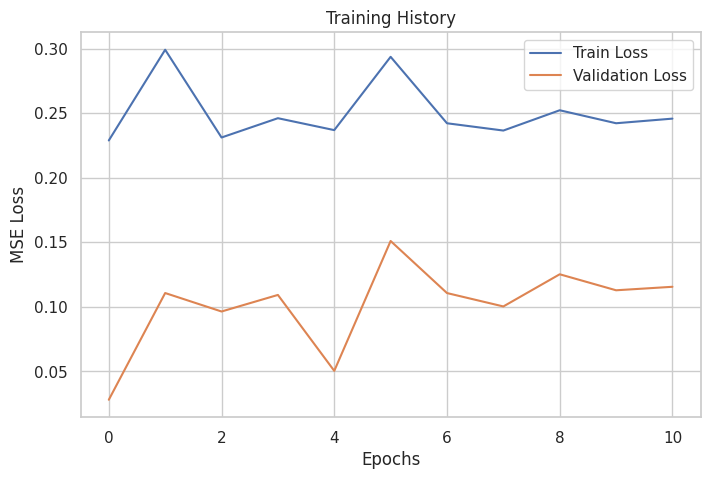

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [6] | 6 ++++++++++++++++++


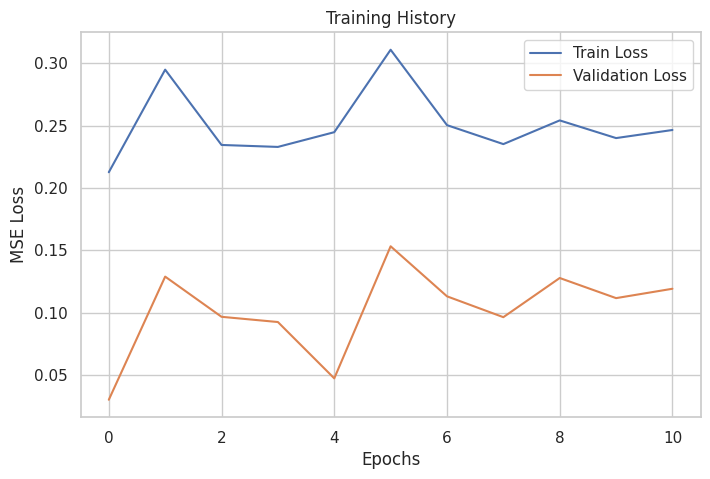

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [6] | 7 ++++++++++++++++++


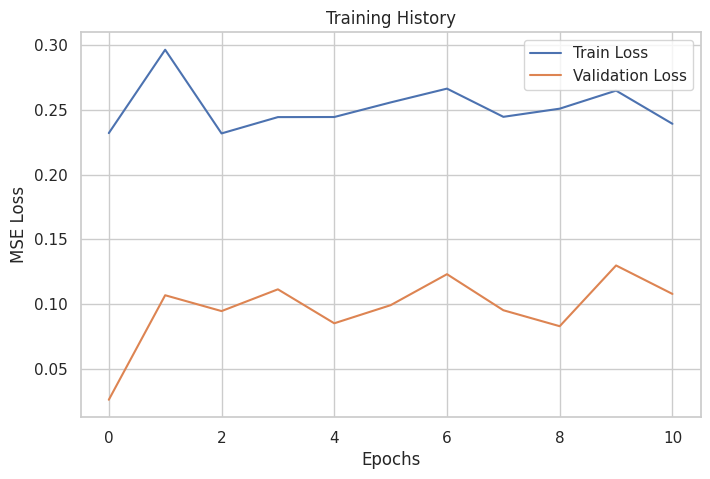

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [6] | 8 ++++++++++++++++++


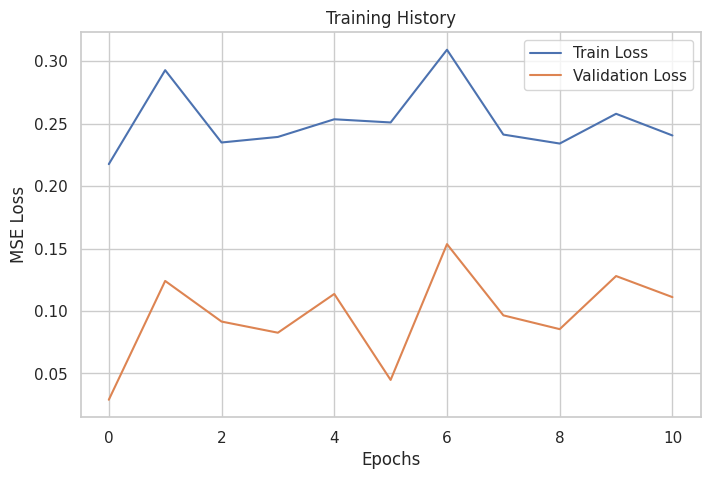

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [6] | 9 ++++++++++++++++++


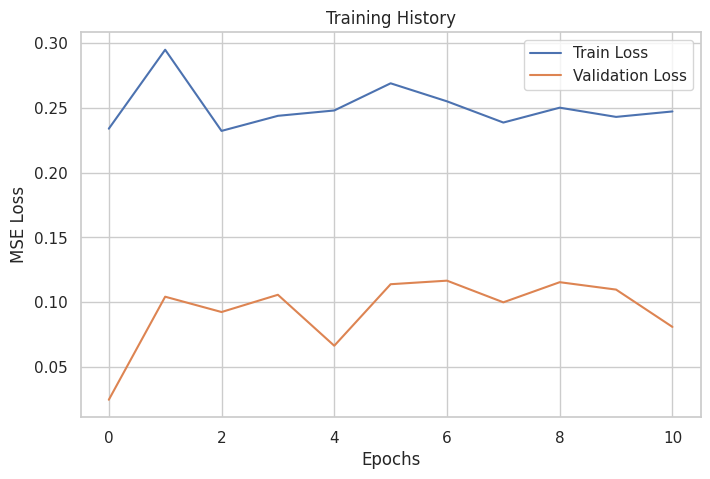

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [6] | 10 ++++++++++++++++++


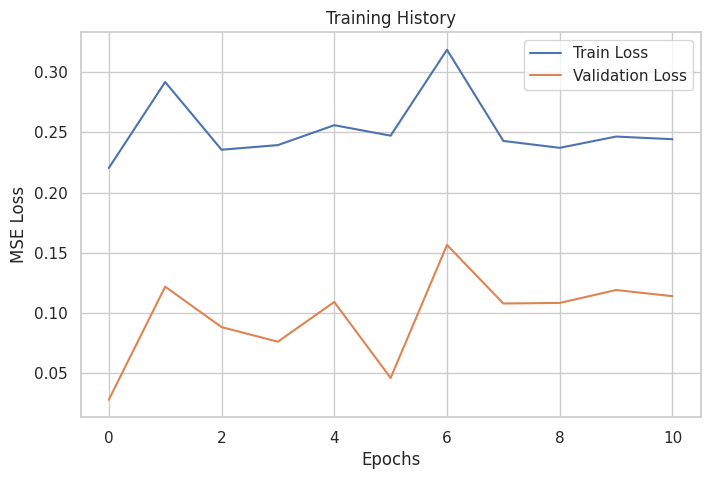

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_6_9,-0.915031,0.227486,2.463119,0.476955,-12.080974,0.390103,1.064482,0.624582,-7.574611,0.017539,1.379176,0.132435
model_6_7,-0.906718,0.226499,2.557149,0.475919,-12.165977,0.392637,1.068661,0.626608,-7.758404,0.017915,1.399100,0.133847
model_6_5,-0.892803,0.224846,2.715850,0.474179,-12.303524,0.396739,1.075567,0.629873,-8.072920,0.018558,1.432654,0.136229
model_6_8,-0.886168,0.224057,2.792173,0.473347,-12.287933,0.396274,1.074748,0.629503,-8.225968,0.018871,1.448746,0.137373
model_6_6,-0.872745,0.222463,2.947661,0.471660,-12.411613,0.399963,1.080956,0.632426,-8.541797,0.019517,1.481487,0.139704
model_6_3,-0.870241,0.222165,2.976834,0.471344,-12.540482,0.403806,1.087218,0.635457,-8.601655,0.019640,1.487623,0.140142
model_6_1,-0.852469,0.220054,3.185533,0.469100,-12.797059,0.411458,1.099473,0.641450,-9.034948,0.020526,1.531421,0.143269
model_6_4,-0.847522,0.219467,3.244137,0.468473,-12.653602,0.407180,1.092633,0.638106,-9.158281,0.020778,1.543695,0.144147
model_4_9,-0.790121,0.212648,3.939881,0.461138,-12.895900,0.414405,1.104556,0.643743,-10.679885,0.023891,1.688813,0.154566
model_4_8,-0.790120,0.212648,3.939887,0.461138,-12.895904,0.414405,1.104556,0.643743,-10.679899,0.023891,1.688814,0.154566


DataFrame salvo em ./content/results/metrics_6
Testando combinacao7: Hidden Size=[10], regularizer=0.1, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 10)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 10)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 10)
+++++++++++ [7] | 1 ++++++++++++++++++


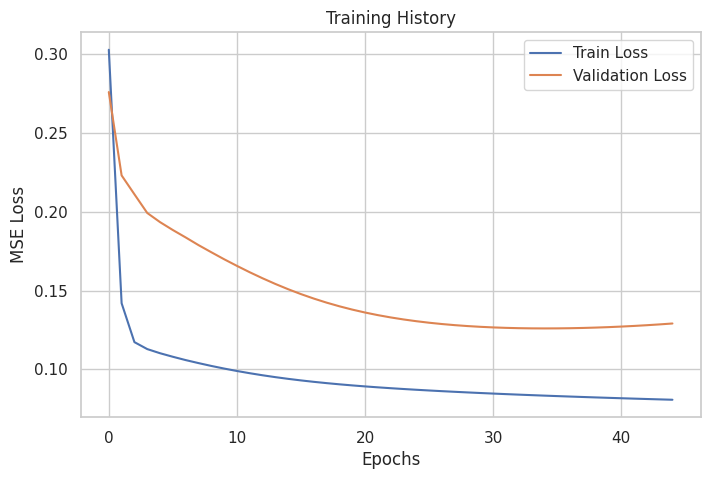

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [7] | 2 ++++++++++++++++++


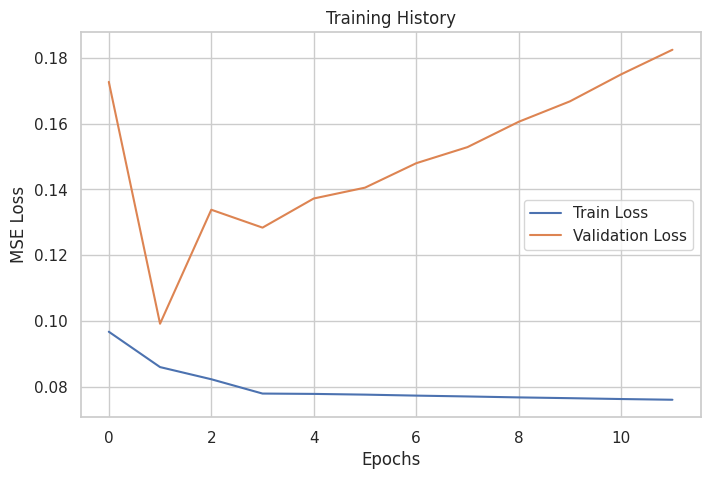

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [7] | 3 ++++++++++++++++++


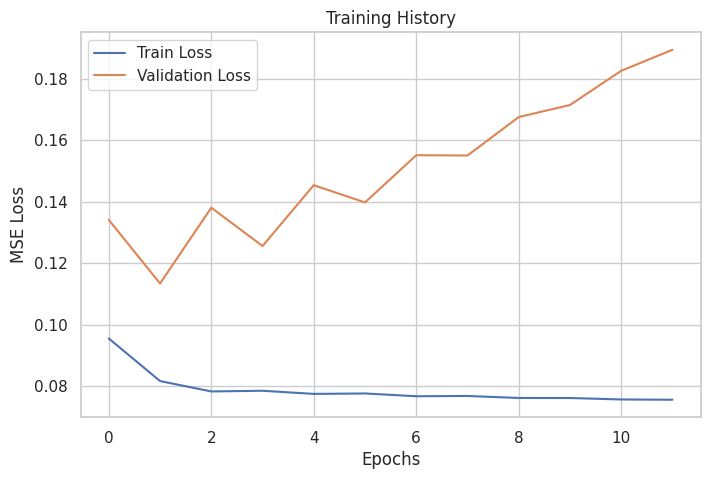

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [7] | 4 ++++++++++++++++++


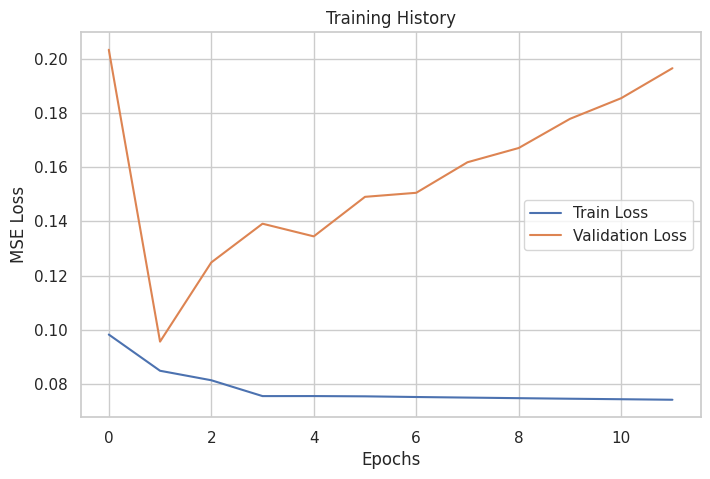

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [7] | 5 ++++++++++++++++++


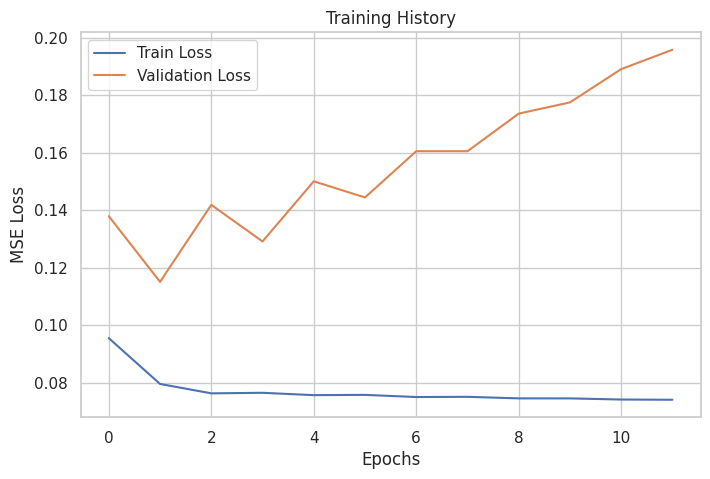

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [7] | 6 ++++++++++++++++++


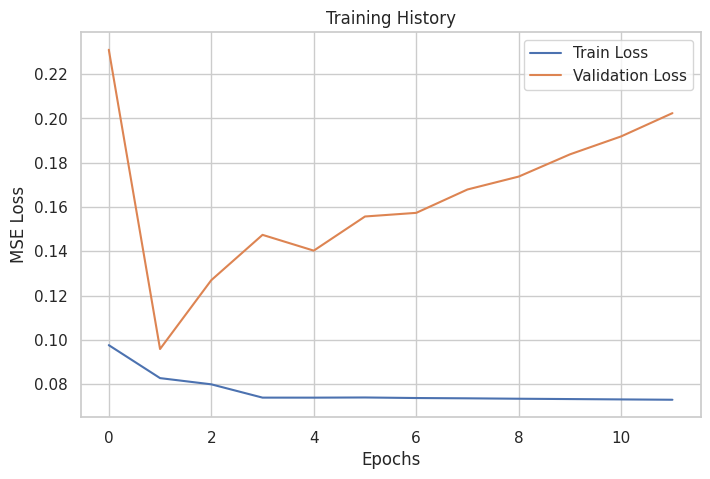

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [7] | 7 ++++++++++++++++++


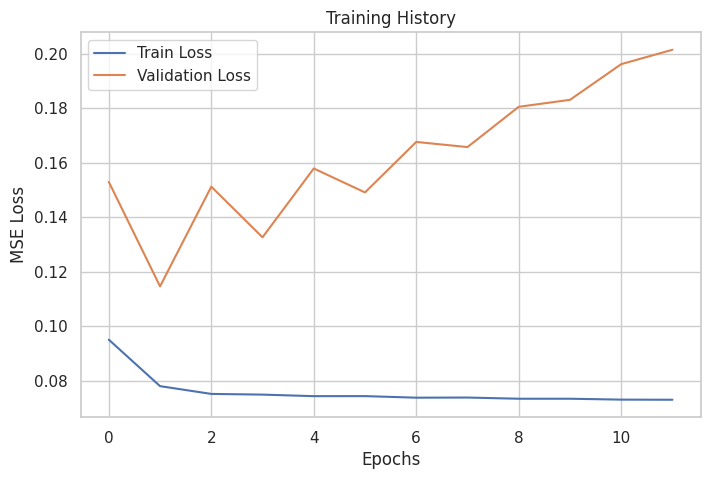

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [7] | 8 ++++++++++++++++++


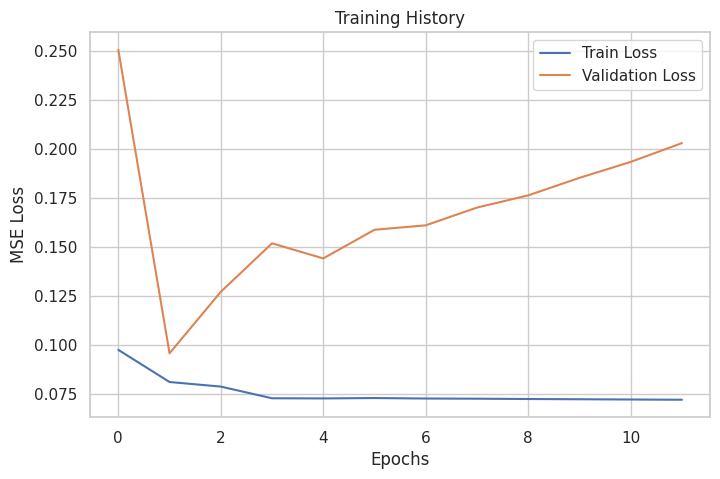

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [7] | 9 ++++++++++++++++++


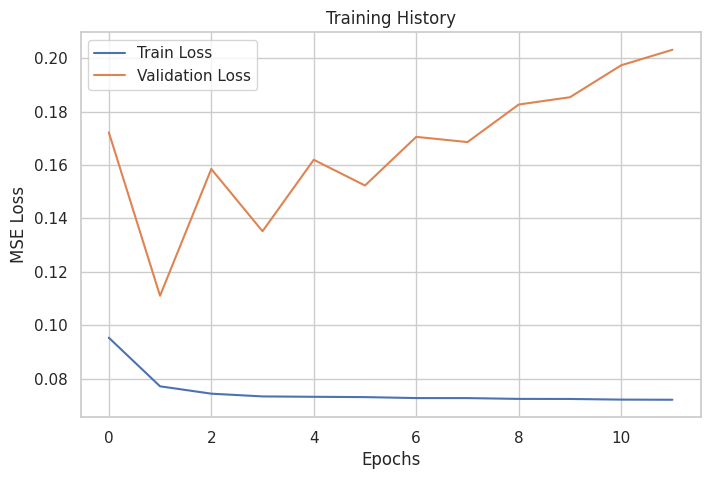

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [7] | 10 ++++++++++++++++++


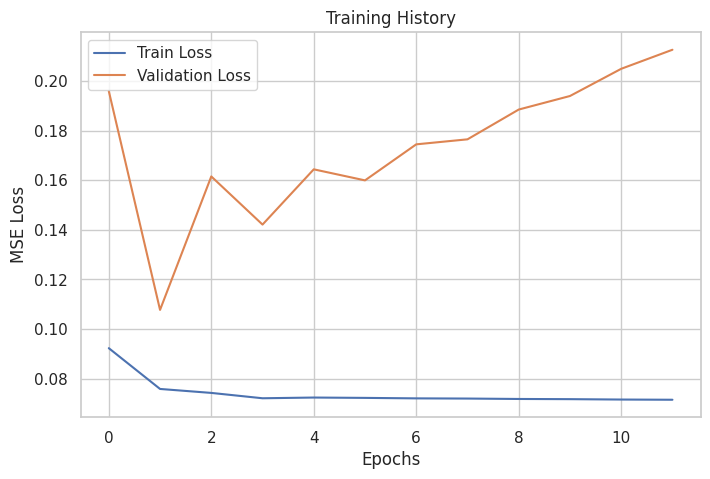

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Testando combinacao8: Hidden Size=[10], regularizer=0.1, learning_rate=0.09
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 10)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 10)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 10)
+++++++++++ [8] | 1 ++++++++++++++++++


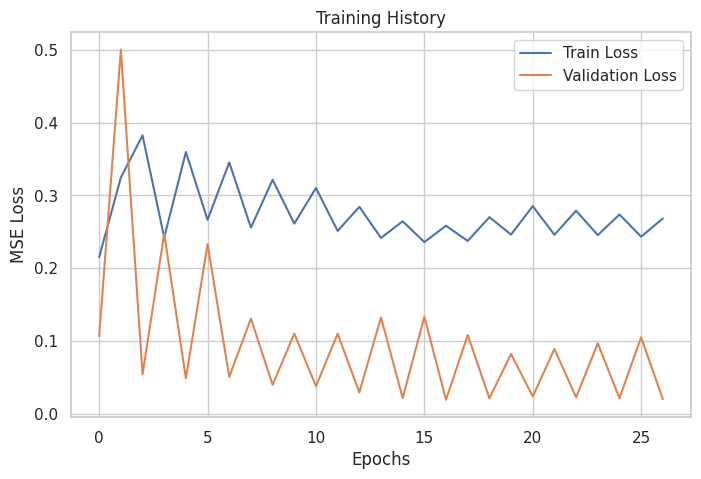

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [8] | 2 ++++++++++++++++++


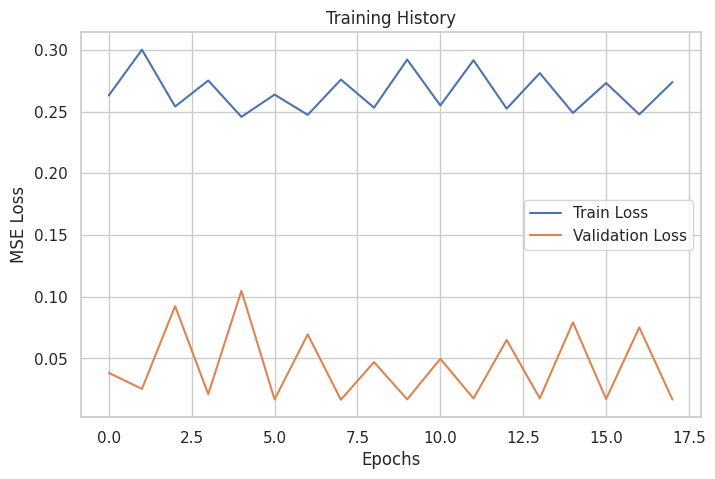

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [8] | 3 ++++++++++++++++++


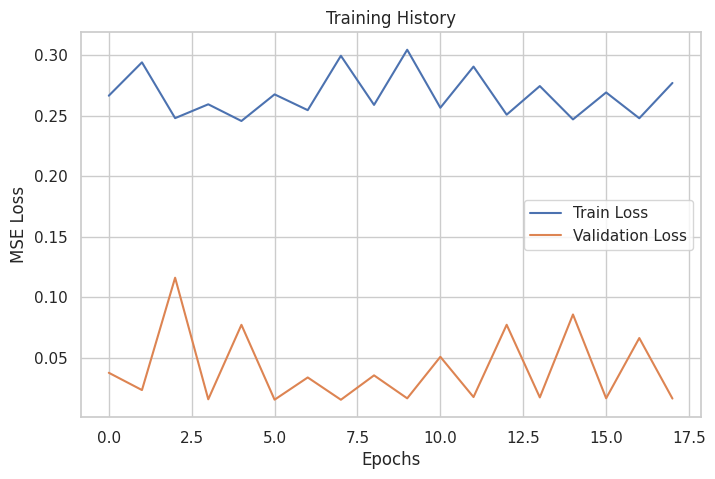

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
+++++++++++ [8] | 4 ++++++++++++++++++


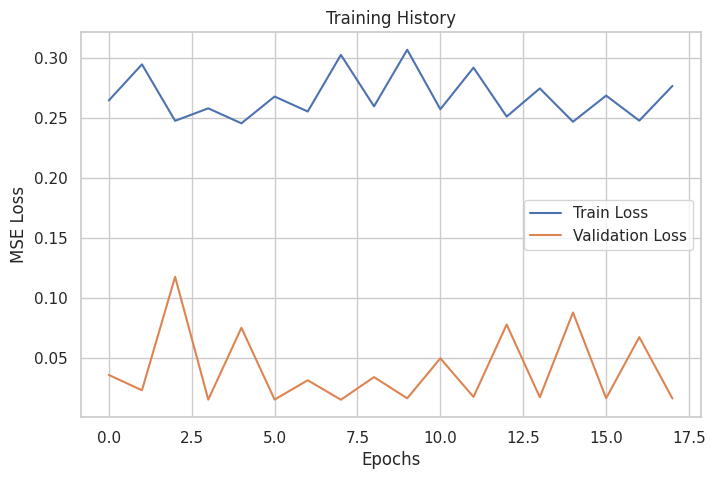

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [8] | 5 ++++++++++++++++++


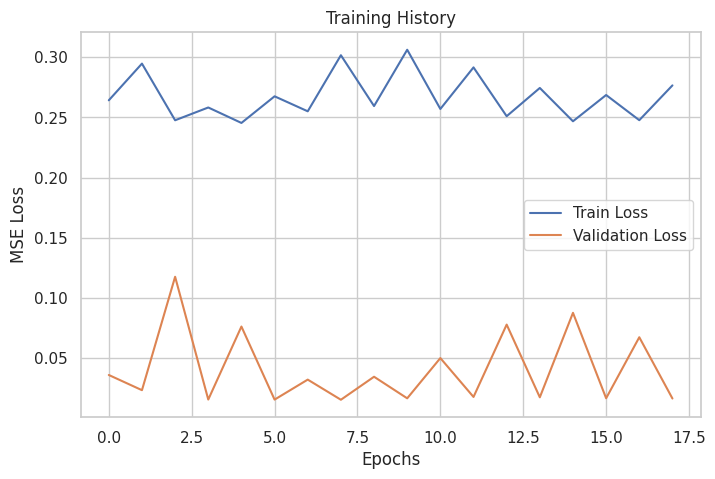

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
+++++++++++ [8] | 6 ++++++++++++++++++


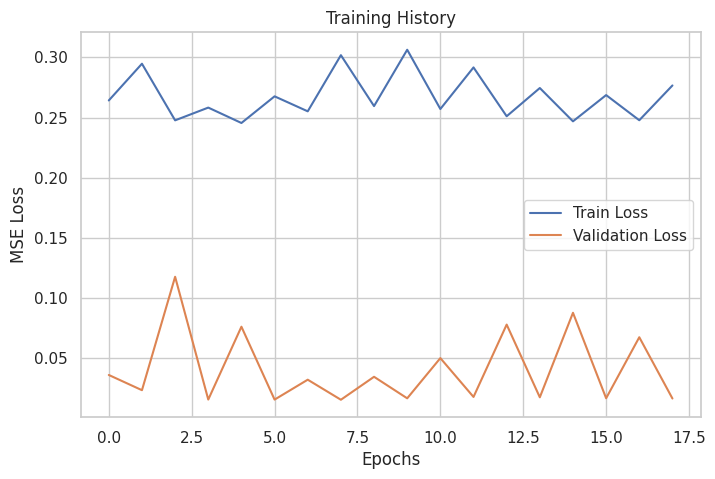

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
+++++++++++ [8] | 7 ++++++++++++++++++


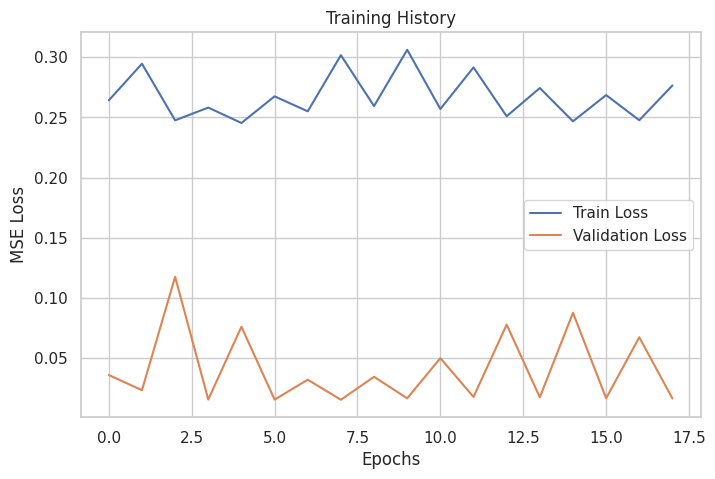

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
+++++++++++ [8] | 8 ++++++++++++++++++


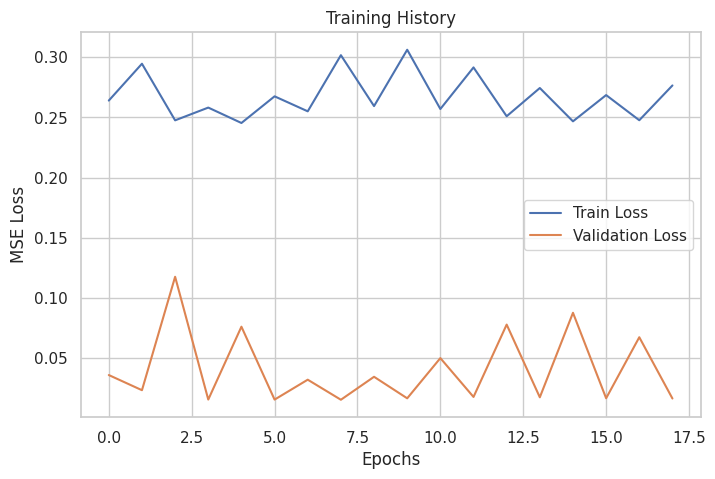

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
+++++++++++ [8] | 9 ++++++++++++++++++


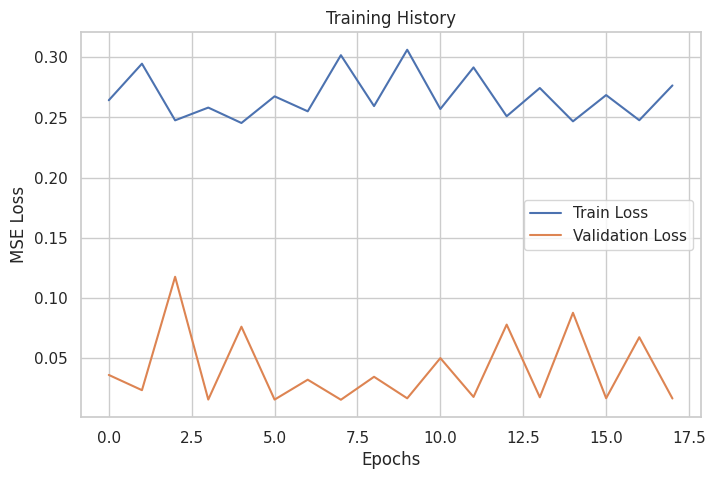

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
+++++++++++ [8] | 10 ++++++++++++++++++


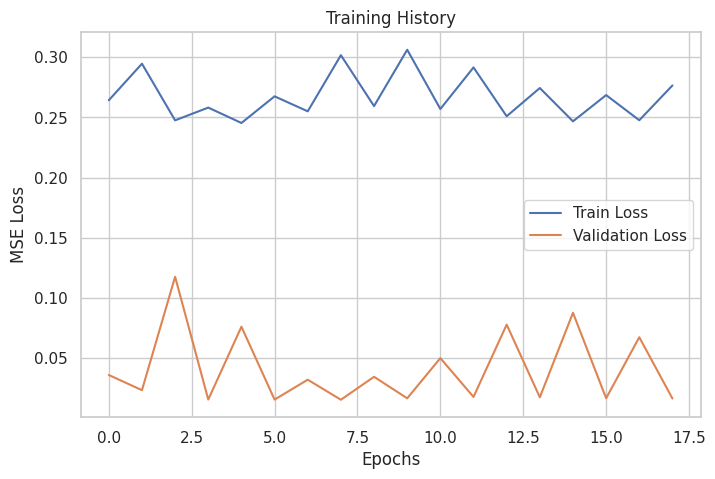

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_8_1,-1.000524,0.237642,1.532590,0.487485,-11.353277,0.368401,1.027447,0.606960,-5.852815,0.014017,1.179312,0.118394
model_8_2,-0.991661,0.236589,1.625807,0.486404,-11.409078,0.370065,1.030325,0.608330,-6.017685,0.014354,1.199625,0.119810
model_8_4,-0.989046,0.236278,1.653471,0.486085,-11.426574,0.370587,1.031226,0.608759,-6.066902,0.014455,1.205634,0.120229
model_8_6,-0.988971,0.236269,1.654268,0.486075,-11.427095,0.370602,1.031252,0.608771,-6.068323,0.014458,1.205808,0.120241
model_8_8,-0.988970,0.236269,1.654275,0.486075,-11.427259,0.370607,1.031261,0.608775,-6.068336,0.014458,1.205809,0.120241
model_8_9,-0.988970,0.236269,1.654278,0.486075,-11.427103,0.370603,1.031253,0.608771,-6.068340,0.014458,1.205810,0.120241
model_8_7,-0.988970,0.236269,1.654280,0.486075,-11.426989,0.370599,1.031247,0.608769,-6.068345,0.014458,1.205810,0.120241
model_8_5,-0.988961,0.236268,1.654366,0.486074,-11.427120,0.370603,1.031254,0.608772,-6.068498,0.014458,1.205829,0.120243
model_8_3,-0.988394,0.236201,1.660379,0.486005,-11.431154,0.370724,1.031461,0.608871,-6.079221,0.014480,1.207135,0.120334
model_8_0,-0.966943,0.233653,1.888441,0.483376,-11.621670,0.376405,1.041215,0.613519,-6.503682,0.015348,1.257905,0.123889


DataFrame salvo em ./content/results/metrics_8
Testando combinacao9: Hidden Size=[15], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 15)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 15)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 15)
+++++++++++ [9] | 1 ++++++++++++++++++


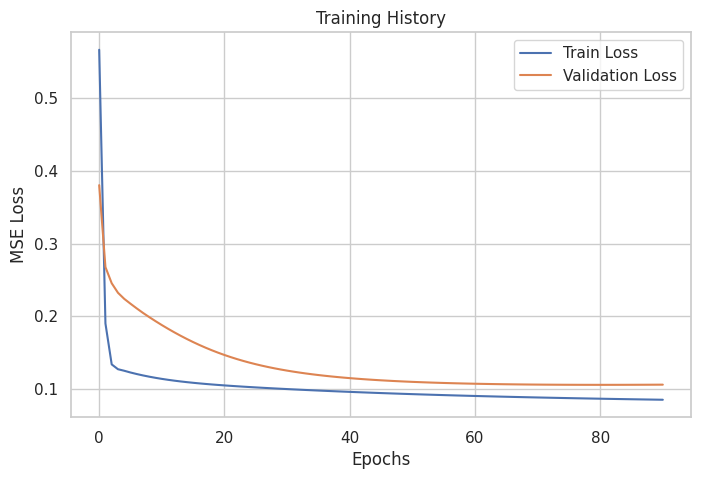

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
+++++++++++ [9] | 2 ++++++++++++++++++


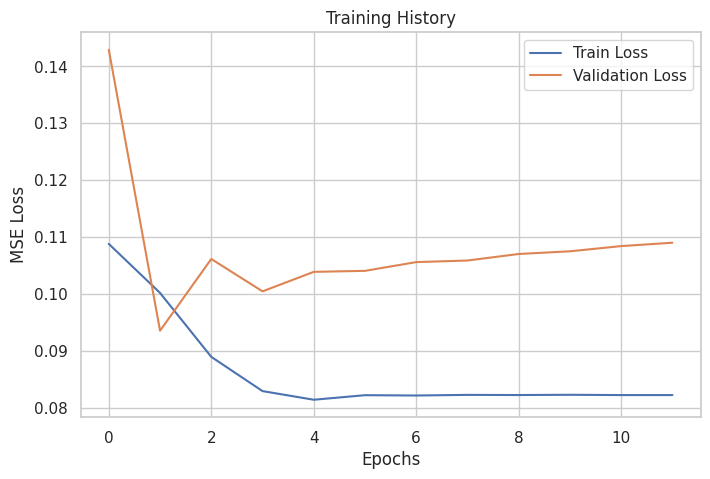

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
+++++++++++ [9] | 3 ++++++++++++++++++


In [ ]:
Valuer.Evaluate(hidden_sizes = [[5], [10], [15], [20], [25]],
            regularizers=[0.2, 0.1],
            learning_rate=[0.01, 0.09],
            run_times = 10, 
            boundarie = 0.5,
            sort_by = 'r2_training',
) 